# A First Monte Carlo Uncertainty Quantification Demo: Longitudinal Strength &rarr; Peak Force

## Why treat progressive damage analysis probabilistically?

NB1 built a single-element model and asked one question: given *this* longitudinal tensile
strength, at *this* boundary condition, what load does the ply carry before damage starts?
That is a deterministic question, and it has a single deterministic answer. But, in general, the longitudinal
tensile strength is a property that composite manufacturers and researchers measure over many nominally identical coupons, and the measured values scatter. Fiber diameter and alignment vary within a tow, resin content and cure quality vary
across a panel, and voids and other manufacturing defects appear unevenly &ndash; all of it changes
the load at which a given ply actually fails, even for material that came off the same
production line with the same nominal layup. [Sriramula & Chryssanthopoulos (2009)](https://doi.org/10.1016/j.compositesa.2009.08.020)
survey this directly: composite structures are subject to significant, well-documented
material and geometric variability, and a stochastic (probabilistic) treatment of that
variability is needed to assess structural reliability with any real confidence &ndash; a purely
deterministic analysis, run once at a single nominal property value, is silent on how
sensitive its answer is to the scatter that property actually has in practice.

**The idea this notebook builds.** If $X_T$ is uncertain, the honest way to carry
that uncertainty through the model is not to guess a single "conservative" value and rerun
NB1's deterministic model once, but to describe $X_T$'s scatter mathematically, as a
**random variable**, and run the *same* deterministic model
many times, once per plausible value of $X_T$. The result is not a single peak force, but a
whole **distribution** of peak forces &ndash; and only once that distribution is in hand can
questions like "how likely is an unusually low peak force?" or "what design value should I
allow for?" be answered with actual evidence instead of an educated guess. That is Monte
Carlo uncertainty quantification (UQ), and this notebook builds the smallest possible working
version of it: one uncertain input, one deterministic Abaqus model, run repeatedly. The end goal of this process is to obtain a trustworthy picture of how $F_{peak}$ is
distributed &ndash; mean, spread, and, crucially, the low-percentile behavior that governs whether a
structure survives.

**Learning objectives**

- Turn NB1's verified single-element model into one input of a Monte Carlo uncertainty
  quantification (UQ) pipeline, by treating its fiber tensile strength $X_T$ as a random
  variable instead of a fixed constant.
- Treat the *output* of the model, $F_{peak}$, as the actual quantity of interest and read a chosen percentile off its distribution once that distribution is
  characterized.
- Understand what a **standard error** actually is, and use it to decide how many Monte Carlo samples are enough &ndash; and see explicitly where that a-priori sizing shortcut stops being available.
- Build a complete, working Monte Carlo pipeline end to end: draw random inputs, run each one
  through the real Abaqus model, and save the full force-displacement and damage history from
  every single run.
- See, concretely, why the *raw* simulated peak force is a biased statistic of the true
  underlying distribution, and how NB1's double-linear-fit reconstruction technique fixes it.
- Just as NB1 ran its single-element model twice (`nlgeom=OFF`, then `nlgeom=ON`), this
  notebook runs **two full Monte Carlo campaigns**, one per `nlgeom` setting, and reads them
  differently: `nlgeom=OFF` as a pipeline check against a known answer, `nlgeom=ON` as the
  actual general-case demonstration.

This notebook is deliberately minimal: one random input, one output, plain Monte Carlo, no surrogate models, no variance-reduction tricks. The goal is a fully working, verified UQ pipeline on the simplest possible case &ndash; everything else is a natural next step.

## Part 1 &ndash; The uncertain input and its exact closed-form consequence

### Why longitudinal strength &rarr; peak force, and why that pairing is special

NB1 built a single-element model of a ply loaded in pure fiber-direction tension, and
verified that damage initiates in the fiber-tension mode the instant the effective stress
$\hat\sigma_{11}$ reaches the longitudinal tensile strength $X_T$ &ndash; in other words, the moment
$F_{ft}=1$ in Hashin's criteria. Up to that instant the model is still perfectly
elastic: no stiffness has degraded yet, so the reaction force is still climbing linearly with
applied displacement.

Once that criterion is met, damage initiates and the model enters the softening branch of its
constitutive law. This means that the reaction force has a peak at the instant of initiation,
and then it starts to decrease as the softening branch takes over. We call this peak
reaction force $F_{peak}$. This is an important quantity to know, because it is the maximum
load the ply can carry before damage starts to degrade its stiffness.

In the small-strain approximation, the peak reaction force is simply equal to the
longitudinal tensile strength $X_T$ times the cross-sectional area of the ply $A$:

$$
F_{peak} = X_T \cdot A.
$$

If $A$ is treated as a constant, this is a **linear** relationship between the input $X_T$
and the output $F_{peak}$.

**Why this pairing is worth choosing for a first UQ demo.** A linear input-output map is the
one case where the *exact* shape of the output distribution can be written down directly from
the shape of the input distribution, with no simulation needed at all. That gives this notebook something a
more complicated model would not have: an independent, closed-form answer to check the entire
Monte Carlo pipeline against.


### From a fixed constant to a random variable

NB1 treated $X_T$ as a fixed number, $990$ MPa, because a deterministic model needs exactly
one value for every input. The introduction above argued that this is not really how $X_T$
behaves &ndash; it scatters from coupon to coupon. Turning that qualitative fact into something a
model can actually use takes two separate ideas, each worth stating on its own before they
get combined.

**Idea 1: an uncertain quantity can be modeled as a random variable.** A random variable is,
informally, a quantity whose value is not fixed in advance but is instead drawn according to
some rule of chance &ndash; rolling a die, measuring the height of the next person to walk through
a door, or here, measuring the tensile strength of the next composite coupon to be pulled to
failure ([Rubinstein & Kroese, 2016](https://doi.org/10.1002/9781118631980), &sect;1.4). Writing
$X_T$ as a random variable is a modeling choice: instead of pretending every ply has exactly
the strength written on a datasheet, it acknowledges directly that repeating "manufacture a
ply and measure its strength" gives a different number each time, and builds that fact into
the model instead of hiding it.

**Idea 2: a random variable is described by a probability distribution.** Saying "$X_T$ is a
random variable" on its own says nothing about *which* values are likely and which are not &ndash;
that information is carried by the random variable's **probability distribution**, a
mathematical object that assigns likelihood to every value (or range of values) the random
variable could take.

**Putting the two ideas together.** Once $X_T$ is a random variable with a distribution, so
is $F_{peak}$: it is computed *from* $X_T$ (via $F_{peak}=X_T\cdot A$ in the small-strain
case, or via the full nonlinear Abaqus model in general), so a different draw of $X_T$
produces a different $F_{peak}$, and $F_{peak}$ inherits a probability distribution of its
own &ndash; shifted and reshaped by whatever the $X_T\to F_{peak}$ mapping happens to do to it.
That output distribution is what this notebook is actually after &ndash; it is the object that lets a later question like "how low could $F_{peak}$ plausibly be?"
be answered with a number instead of a guess.

**Why a percentile, not just the mean.** Once $F_{peak}$ has a distribution, the most natural
summary to reach for is its mean &ndash; but the mean is the wrong number to design against. A
structure might not fail because the strength of its *typical* ply is not enough; it might fail
because *some* ply, somewhere, turns out to be on the weak side of the scatter, and that unlucky ply is exactly
the one the design has to survive. That is why, alongside the mean, it is important to track a **percentile** $Q_p$ of the distribution of the quantity of interest &ndash;
the value that a fraction $p$ of the population falls at or below &ndash; and to treat a low
percentile (the 1st, 5th, or 10th, say) as at least as important a target as the mean.


### Choosing a distribution for $X_T$

**What a normal distribution is.** The normal (or Gaussian) distribution is the familiar
symmetric, bell-shaped distribution, fully described by just two numbers: a **mean** $\mu$
(where the bell is centered &ndash; the most likely value, and also the average of infinitely many
draws) and a **standard deviation** $\sigma$ (how wide the bell is &ndash; how far a typical draw
strays from $\mu$). A convenient way to express scatter *relative* to the mean, used
throughout this notebook, is the **coefficient of variation**, $\text{CoV}=\sigma/\mu$: a
CoV of 5% means the typical draw is within about 5% of the mean, regardless of what the mean
itself happens to be.

**Why normal, here.** This is a deliberate simplification, not a claim that it is the most
physically accurate choice: a normal distribution is fully specified by two familiar numbers,
its properties are the simplest to work with in closed form, and it lets this first UQ demo focus on building and
verifying the *pipeline* &ndash; the sampling, the Abaqus loop, the reconstruction, the statistical
checks &ndash; without also having to justify a more elaborate distributional model at the same
time. A more defensible choice for a strength property specifically is discussed at the end
of this section.

**What a probability density function is.** A random variable's distribution is often drawn
as a **probability density function (PDF)** &ndash; a curve $f(x)$ such that the *area* under the
curve between two values $a$ and $b$ equals the probability that a draw of the random
variable lands between $a$ and $b$. The height of the curve at a single point is not itself a
probability (a single exact value has zero probability for a continuous random variable like
$X_T$); only areas under the curve are. The total area under any PDF is exactly 1, since the
random variable has to take *some* value. For the normal distribution, the PDF has the
closed-form expression

$$
f(x;\mu,\sigma) = \frac{1}{\sigma\sqrt{2\pi}}\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right),
$$

plotted below for the specific $\mu,\sigma$ this notebook uses.

**The numbers used here:**

$$
X_T \sim \mathcal{N}(\mu=990\ \text{MPa},\ \sigma \approx 49.5\ \text{MPa}), \qquad
\text{CoV} = \sigma/\mu = 5\%.
$$

$\mu=990$ MPa is the longitudinal tensile strength of a fiberglass-reinforced epoxy ply reported by [Nelson et al. (2017)](https://doi.org/10.5194/wes-2-653-2017) and already used in NB1. Nelson et al. report only this point value, with no scatter statistics at all &ndash; the 5% CoV is not sourced from them. Instead, it is chosen as a representative order of magnitude for composite strength scatter, informed by the review of stochastic FRP composite properties in [Sriramula & Chryssanthopoulos (2009)](https://doi.org/10.1016/j.compositesa.2009.08.020), who compile CoV values reported across the composites literature for this kind of strength property. Treat $\sigma=49.5$ MPa as this notebook's own illustrative modeling choice, not a measured value for this specific material.

**A caveat worth naming, and a forward pointer.** A normal distribution technically assigns
some (tiny) probability to $X_T<0$, which is unphysical &ndash; a material cannot have negative
strength. At a 5% CoV this negative tail is negligible enough to ignore for this
demonstration, but the honest statement is that the normal distribution *permits* it while
the true physical distribution of a strength property does not. This is exactly the kind of
gap [Sriramula & Chryssanthopoulos (2009)](https://doi.org/10.1016/j.compositesa.2009.08.020)
flag when they discuss distribution selection for composite properties, and it is why the
standard distributional choice for a brittle-fiber tensile strength specifically is not the
normal but the [Weibull (1951)](https://doi.org/10.1115/1.4010337) distribution: it is derived
from *weakest-link theory* (a fiber is only as strong as its weakest flaw, so extreme-value
statistics, not averaging statistics, govern its strength scatter), is bounded below by zero,
and is the standard choice used in stochastic-composites literature. This notebook keeps the normal distribution for its analytical convenience and defers the switch to Weibull to a later notebook, once the Monte Carlo pipeline itself is verified.

The cell below defines $\mu$ and $\sigma$ in code and plots the theoretical PDF this choice
implies.


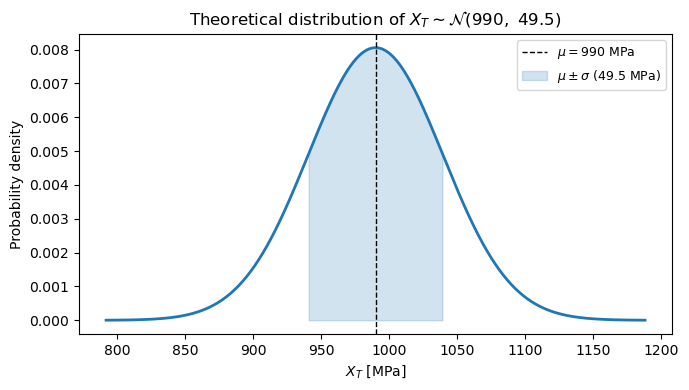

In [1]:
import matplotlib.pyplot as plt
import numpy as np

MU = 990.0     # MPa, fiber tensile strength X_T - Nelson, Riddle & Cairns (2017), Table 2
SIGMA = 49.5   # MPa, 5% CoV - illustrative scatter, NOT from Nelson et al. (see above)


def gaussian_pdf(x, mu, sigma):
    """Normal probability density function f(x; mu, sigma) - used throughout this notebook
    to overlay the theoretical distribution on top of sampled/simulated data. Implements the
    closed-form expression given above directly (no scipy dependency needed for something
    this simple)."""
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))


# x_grid spans +-4 standard deviations around the mean, which comfortably covers essentially
# all of the distribution's probability mass. Reused for every later plot in this notebook
# that overlays the theoretical PDF on top of sampled/simulated data, so every such plot uses
# the same x-range and is directly comparable to this one.
x_grid = np.linspace(MU - 4 * SIGMA, MU + 4 * SIGMA, 400)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_grid, gaussian_pdf(x_grid, MU, SIGMA), color="C0", lw=2)
ax.axvline(MU, color="k", ls="--", lw=1, label=f"$\\mu={MU:.0f}$ MPa")
# Shade the +-1 sigma band: by the 68-95-99.7 rule for a normal distribution, this shaded
# area is about 68% of the total area under the curve, i.e. P(mu - sigma < X_T < mu + sigma).
ax.fill_between(x_grid, gaussian_pdf(x_grid, MU, SIGMA),
                where=(x_grid >= MU - SIGMA) & (x_grid <= MU + SIGMA),
                color="C0", alpha=0.2, label=f"$\\mu\\pm\\sigma$ ({SIGMA:.1f} MPa)")
ax.set_xlabel("$X_T$ [MPa]")
ax.set_ylabel("Probability density")
ax.set_title(r"Theoretical distribution of $X_T \sim \mathcal{N}(990,\ 49.5)$")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


The plot above is the theoretical PDF this notebook samples from throughout: symmetric, centered
on $\mu=990$ MPa, with the shaded band showing where about 68% of the probability mass sits
($\mu\pm\sigma$). At this CoV the curve is visibly nowhere near zero MPa &ndash; consistent with the
caveat above that the normal distribution's unphysical negative tail is negligible here, even
though it is technically nonzero.


### The output distribution in the small-strain limit

$X_T$ now has a distribution, $X_T\sim\mathcal N(\mu, \sigma)$ with $\mu=990$ MPa and
$\sigma=49.5$ MPa. Because $F_{peak}=A\cdot X_T$ is a **linear transform** of $X_T$, its distribution can be written
down directly, with no sampling and no simulation at all:

$$
F_{peak} = A\cdot X_T \sim \mathcal{N}(A\mu,\ A\sigma).
$$

A linear transform of a Normal random variable is itself Normal, simply rescaled and
re-centered by the same constant $A$ &ndash; a standard fact about the Normal distribution, not
something specific to this model. This is the payoff of choosing this particular,
deliberately simple input-output pairing for a first UQ demo: the *exact* output distribution
is available before a single Abaqus job runs.

**From a distribution to a percentile.** For a Normal random variable, the $p$-th percentile
(the value $Q_p$ such that a fraction $p$ of the population falls at or below it) has the
closed form

$$
Q_p = \mu + z_p\,\sigma,
$$

where $z_p$ is the standard Normal distribution's own $p$-th percentile (a fixed number,
independent of $\mu,\sigma$) &ndash; formally, the value satisfying $\Phi(z_p)=p$ for the standard
Normal cumulative distribution function $\Phi$. There is no closed-form expression for this inverse,
so the cell below evaluates it numerically, via `scipy.stats.norm.ppf`, for the three
percentiles this notebook returns to repeatedly: 1%, 5%, and 10%.


In [2]:
from scipy.stats import norm

# z_p is the p-th percentile of the STANDARD normal distribution N(0,1): the value z such
# that Phi(z) = p, where Phi is the standard normal CDF. No closed form exists for this
# inverse CDF ("probit" function), so it has to be evaluated numerically -
# scipy.stats.norm.ppf ("percent point function") does exactly that.
Z_P = {"1%": float(norm.ppf(0.01)), "5%": float(norm.ppf(0.05)), "10%": float(norm.ppf(0.10))}
z_p_labels = {p: p.replace("%", r"\%") for p in Z_P.keys()}  # LaTeX-escaped percent sign, for legend labels later

print(f"{'p':<6s}{'z_p':>8s}")
for p, z in Z_P.items():
    print(f"{p:<6s}{z:8.3f}")


p          z_p
1%      -2.326
5%      -1.645
10%     -1.282


Applying the same linear map to the percentile itself gives $F_{peak}$'s percentile directly: $Q_p(F_{peak}) = A\cdot Q_p(X_T) = A(\mu+z_p\sigma)$ &ndash; no separate derivation needed, because a percentile of a linearly-transformed Normal variable transforms exactly the same way the variable itself does. The cell below plots the three percentiles on top of the full PDF of $X_T$ and $F_{peak}$.


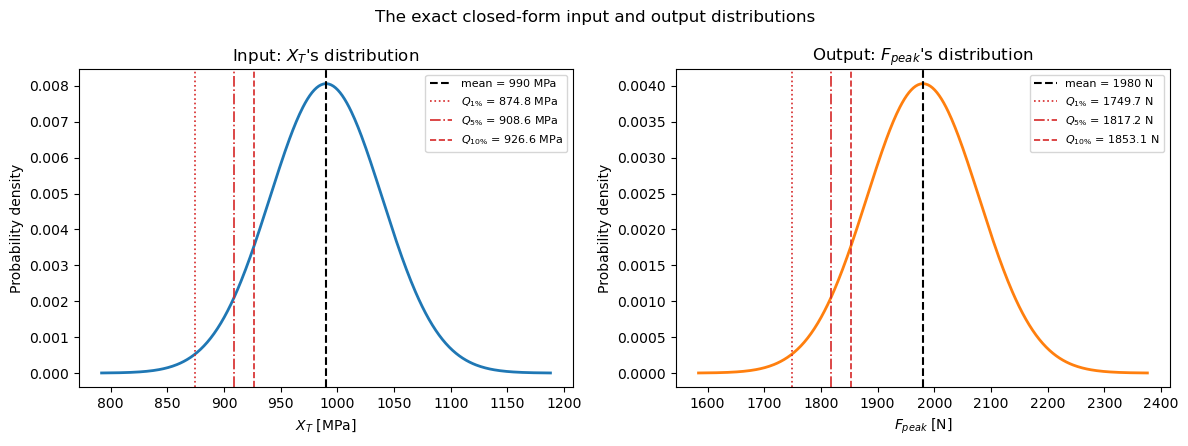

X_T:      mean=990.00 MPa, std=49.50 MPa, Q_1%=874.85 MPa, Q_5%=908.58 MPa, Q_10%=926.56 MPa
F_peak:   mean=1980.00 N, std=99.00 N, Q_1%=1749.69 N, Q_5%=1817.16 N, Q_10%=1853.13 N


In [3]:
# Cross-sectional area of the single-element model
A = 10.0 * 0.2  # mm^2 - gauge width (10 mm) times ply thickness (0.2 mm), both NB1's geometry

# The two analytical predictions this notebook will check both Monte Carlo campaigns
# against: (1) the linear input-output map itself, and (2) the Gaussian output distribution
# it implies. Both follow directly from F_peak = A * X_T being a linear transform of a
# Normal random variable.
analytical_mean = A * MU     # N, predicted mean peak force
analytical_std = A * SIGMA   # N, predicted std of peak force

# Percentiles of X_T (input) and F_peak (output), both from the same closed form
# Q_p = mu + z_p*sigma (F_peak's version simply uses A*mu, A*sigma in place of mu, sigma).
x_t_percentiles = {p: MU + z * SIGMA for p, z in Z_P.items()}
f_peak_percentiles = {p: analytical_mean + z * analytical_std for p, z in Z_P.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(x_grid, gaussian_pdf(x_grid, MU, SIGMA), color="C0", lw=2)
axes[0].axvline(MU, color="k", ls="--", lw=1.5, label=f"mean = {MU:.0f} MPa")
for (p, val), ls in zip(x_t_percentiles.items(), [":", "-.", "--"]):
    axes[0].axvline(val, color="C3", ls=ls, lw=1.2, label=f"$Q_{{{z_p_labels[p]}}}$ = {val:.1f} MPa")
axes[0].set_xlabel("$X_T$ [MPa]")
axes[0].set_ylabel("Probability density")
axes[0].set_title("Input: $X_T$'s distribution")
axes[0].legend(fontsize=8)

f_grid = np.linspace(analytical_mean - 4 * analytical_std, analytical_mean + 4 * analytical_std, 400)
axes[1].plot(f_grid, gaussian_pdf(f_grid, analytical_mean, analytical_std), color="C1", lw=2)
axes[1].axvline(analytical_mean, color="k", ls="--", lw=1.5, label=f"mean = {analytical_mean:.0f} N")
for (p, val), ls in zip(f_peak_percentiles.items(), [":", "-.", "--"]):
    axes[1].axvline(val, color="C3", ls=ls, lw=1.2, label=f"$Q_{{{z_p_labels[p]}}}$ = {val:.1f} N")
axes[1].set_xlabel("$F_{peak}$ [N]")
axes[1].set_ylabel("Probability density")
axes[1].set_title(r"Output: $F_{peak}$'s distribution")
axes[1].legend(fontsize=8)

fig.suptitle("The exact closed-form input and output distributions")
fig.tight_layout()
plt.show()

print(f"X_T:      mean={MU:.2f} MPa, std={SIGMA:.2f} MPa, " +
      ", ".join(f"Q_{p}={v:.2f} MPa" for p, v in x_t_percentiles.items()))
print(f"F_peak:   mean={analytical_mean:.2f} N, std={analytical_std:.2f} N, " +
      ", ".join(f"Q_{p}={v:.2f} N" for p, v in f_peak_percentiles.items()))


The two panels above are the same bell shape, only rescaled: the right panel is exactly the left one stretched (and shifted) by the constant $A=2\ \text{mm}^2$. Every percentile moves the same way.


### Why this closed form is the exception, not the rule

The way the entire distribution of $F_{peak}$ &ndash; mean, std, and every percentile &ndash; fell
straight out of $X_T$'s own distribution is not how things work in general. The moment the
input-output map is anything other than exactly linear &ndash; a real laminate, a model with more
than one uncertain property, or even this same model once `nlgeom=ON` introduces genuine
nonlinearity &ndash; there is no closed form left to write down. The only way to find out how
$F_{peak}$ is actually distributed is to draw a finite number of samples of the input
uncertain parameter $X_T$, run each one through the real (in this case, Abaqus) model, and
build up the output distribution empirically from the resulting set of simulated outputs. This is exactly the Monte Carlo approach and what we are going to introduce in the next section.


## Part 2 &ndash; How many samples do we need?

### From a closed form to Monte Carlo simulation

Executing a **Monte Carlo simulation** means drawing $N$ random samples of an uncertain input, run the same deterministic model once per sample, and treat the resulting $N$ simulated outputs as an empirical stand-in for the output's true
distribution [(Rubinstein & Kroese, 2016)](https://doi.org/10.1002/9781118631980). The idea
itself is simple; the question that actually decides whether it is useful is **how large $N$
needs to be**. In general this cannot be worked out ahead of time &ndash; there is no formula to
invert, because there is no formula for the output distribution to begin with &ndash; so $N$ has
to be judged from the simulation results themselves, by checking how much they change as more
samples are added.

**This notebook is the exception, and deliberately so.** Because $F_{peak}=A\cdot X_T$ is
known to be an exactly linear map of a Normal random variable, the sample size $N$ can be
derived analytically, from a target precision, *before* a single Abaqus job runs &ndash;
something a general problem would not allow. The rest of this Part does exactly that. Successively, we will run the resulting $N$-sample Monte Carlo campaign twice, once with a linear element formulation (`nlgeom=OFF`), and once with the nonlinear element formulation (`nlgeom=ON`). In this way, we will be able to compare the empirical results of the linear formulation against the closed form, and see what a case with **no** closed form to check against actually looks like.


### Monte Carlo estimates and their standard error

Given $N$ sampled values $X_1,\dots,X_N$ of a random variable (here, $N$ draws of $X_T$), a
**Monte Carlo estimate** of a summary quantity is simply that summary computed from the
finite sample instead of from the full population. The two estimators this notebook needs are
the sample mean and the sample standard deviation,

$$
\widehat\mu = \bar X = \frac{1}{N}\sum_{i=1}^N X_i, \qquad
\widehat\sigma = \sqrt{\frac{1}{N-1}\sum_{i=1}^N (X_i-\bar X)^2}.
$$

Both are **unbiased**: their average value, over infinitely many repeated batches of $N$
samples, equals the true $\mu$ and $\sigma$ exactly
[(Rubinstein & Kroese, 2016)](https://doi.org/10.1002/9781118631980) &ndash; which is *why*
$\widehat\sigma$ divides by $N-1$, not $N$ (Bessel's correction): dividing by $N$ would
systematically underestimate $\sigma$. This notebook uses `ddof=1` (the $N-1$ divisor) in
every `.std()` call for this reason.

Every time $N$ fresh samples are drawn, $\widehat\mu$ and $\widehat\sigma$ come out slightly
different. The **standard error (SE)** of an estimator is the standard deviation *of that
estimator itself*, across this hypothetical population of "repeat the whole experiment with a
fresh batch of $N$ samples" &ndash; it answers *if this sampling procedure were run over and
over, how far would a typical run's estimate land from the true value?* Note the difference with $\sigma$, standard deviation of the population: $\sigma$ describes how far a *single* draw of $X_T$ strays from $\mu$, fixed
regardless of $N$; $SE$ describes how far a *summary statistic computed from $N$ draws*
strays from the truth, and it shrinks as $N$ grows. A **confidence interval** of an estimate $\widehat\ell$,
$\widehat\ell\pm k\cdot SE(\widehat\ell)$, turns that spread into a stated probability of
containing the truth: for an approximately Normal estimator, $k=2$ gives roughly a 95%
confidence level, meaning that 95% of repeated batches of $N$ samples would produce an interval that contains the true population parameter $\ell$$. The 95% confidence interval is the one employed throughout this notebook.


### How fast do these estimates converge?

[Ahn & Fessler (2003)](https://web.eecs.umich.edu/~fessler/papers/files/tr/stderr.pdf) give
the standard error of both estimators above, for a sample drawn from $\mathcal N(\mu,\sigma)$:

$$
SE(\widehat\mu) = \frac{\sigma}{\sqrt N}, \qquad
SE(\widehat\sigma) \approx \frac{\sigma}{\sqrt{2(N-1)}} \quad (\text{large-}N\text{ approximation}).
$$

Both shrink like $1/\sqrt N$ &ndash; the hallmark Monte Carlo convergence rate. To compare the
two, and to set a tolerance in the percentage terms engineers actually think in, this notebook
uses the **relative standard error**, $SE(\widehat\ell)/\ell$
[(Rubinstein & Kroese, 2016)](https://doi.org/10.1002/9781118631980):

$$
\text{relSE}(\widehat\mu) = \frac{\sigma}{\mu\sqrt N} = \frac{\text{CoV}}{\sqrt N}, \qquad
\text{relSE}(\widehat\sigma) \approx \frac{1}{\sqrt{2(N-1)}},
$$

where $\ell$ is the true value of the quantity being estimated.

In *absolute* terms $SE(\widehat\sigma)$ is smaller than $SE(\widehat\mu)$ for the same $N$
(by roughly $\sqrt2$) &ndash; so it might seem like $\sigma$ should always be easier to pin down.
But $SE(\widehat\sigma)$ is measured *relative to $\sigma$ itself*, which in our case is about 20 times smaller than
$\mu$, so once both are expressed as *relative* errors the comparison flips: at $N=2$, $\text{relSE}(\widehat\mu)$ is already a modest 3.5%, while $\text{relSE}(\widehat\sigma)$ still exceeds 70%. **The scatter is generally the harder quantity to pin down, in relative
terms &ndash; and, as the next section shows, it is the scatter that any low-percentile estimate
depends on most.**


### The target: trusting the weak tail of $F_{peak}$'s distribution

The goal of this whole exercise is not "estimate $F_{peak}$'s mean well" &ndash; it is to
characterize $F_{peak}$'s distribution well enough that its **weak tail** can be trusted: the
low percentiles that tell a designer how bad an unlucky ply can plausibly be, which is exactly
the information a mean cannot provide. Concretely, that means setting a target relative standard error on a chosen percentile $Q_p$ of $F_{peak}$'s distribution:

$$
\text{relSE}\big(\widehat{Q_p}(F_{peak})\big) \le \text{target}.
$$

Because $F_{peak}=A\cdot X_T$ is an exactly linear map, a percentile of $F_{peak}$ is simply
$A$ times the same percentile of $X_T$, that is to say $Q_p(F_{peak})=A\cdot Q_p(X_T)$, and that same
scaling carries through to the estimator's standard error:

$$
\widehat{Q_p}(F_{peak}) = A\cdot\widehat{Q_p}(X_T)
\;\Longrightarrow\;
SE\big(\widehat{Q_p}(F_{peak})\big) = A\cdot SE\big(\widehat{Q_p}(X_T)\big)
\;\Longrightarrow\;
\text{relSE}\big(\widehat{Q_p}(F_{peak})\big) = \frac{A\cdot SE(\widehat{Q_p}(X_T))}{A\cdot Q_p(X_T)} = \text{relSE}\big(\widehat{Q_p}(X_T)\big).
$$

The constant $A$ cancels exactly out of the *relative* error. In practice, this means the
target can be set, and the required sample size derived, entirely in terms of $X_T$ &ndash; so no
Abaqus run needed for this part of the analysis.

For a Normal population, the percentile estimator is built from $\widehat\mu$ and
$\widehat\sigma$ the same way the true percentile is built from $\mu$ and $\sigma$:

$$
\widehat{Q_p} = \widehat\mu + z_p\,\widehat\sigma.
$$

Any target percentile with $p<50\%$ has $z_p<0$, so $\widehat\sigma$ enters directly in the error calculation: even a *perfect* estimate of $\mu$ still leaves $Q_p$ off by $|z_p|$ times whatever error remains in $\widehat\sigma$ &ndash; and the deeper into the tail $p$ sits, the
larger $|z_p|$ is, so the more that error gets amplified. That is the concrete reason
$\widehat\sigma$ has to be sized on equal footing with $\widehat\mu$ below, not folded in as a
secondary check.


### From the target to a required $N$

$\widehat{Q_p}=\widehat\mu+z_p\widehat\sigma$ combines two estimators linearly. To find its
standard error it helps to first go through **variance**, defined here simply as the square of
the standard error, $\mathrm{Var}(\widehat\ell) \equiv SE(\widehat\ell)^2$ (equivalently,
$SE(\widehat\ell)=\sqrt{\mathrm{Var}(\widehat\ell)}$) &ndash; nothing new is being assumed, only a
name given to a squared quantity. The reason to detour through it at all is that **variances of
independent quantities add, while standard errors do not**: the square root of a sum is not the
sum of the square roots, $\sqrt{a+b}\neq\sqrt a+\sqrt b$. So the two error sources below are
combined in variance, and converted back to a standard error by a single square root at the very
end, not before.

For two random quantities $U,V$ and constants $a,b$, the variance of their linear combination is

$$
\mathrm{Var}(aU+bV) = a^2\mathrm{Var}(U) + b^2\mathrm{Var}(V) + 2ab\,\mathrm{Cov}(U,V),
$$

where $\mathrm{Cov}(U,V)$, the **covariance** of $U$ and $V$, measures how much the two move
together &ndash; positive if they tend to rise and fall together, zero if they are independent.
Four steps turn this general identity into $SE(\widehat{Q_p})$:

1. **Apply the identity** with $U=\widehat\mu$, $V=\widehat\sigma$, $a=1$, $b=z_p$ (matching
   $\widehat{Q_p}=\widehat\mu+z_p\widehat\sigma$):
   $$
   \mathrm{Var}(\widehat{Q_p}) = \mathrm{Var}(\widehat\mu) + z_p^2\,\mathrm{Var}(\widehat\sigma) + 2z_p\,\mathrm{Cov}(\widehat\mu,\widehat\sigma).
   $$
2. **Drop the covariance term.** For a sample drawn from a Normal population, $\bar X$ and
   $\widehat\sigma$ are independent
   [(Casella & Berger, 2024)](https://doi.org/10.1201/9781003456285), so
   $\mathrm{Cov}(\widehat\mu,\widehat\sigma)=0$ and the last term vanishes.
3. **Substitute $\mathrm{Var}=SE^2$ back in**, using the definition from the top of this section:
   $$
   SE(\widehat{Q_p})^2 = SE(\widehat\mu)^2 + z_p^2\,SE(\widehat\sigma)^2.
   $$
4. **Take the square root once, at the very end** &ndash; not before, and not term by term &ndash; to
   get back to a standard error:
   $$
   SE(\widehat{Q_p}) = \sqrt{SE(\widehat\mu)^2 + z_p^2\,SE(\widehat\sigma)^2}.
   $$

This &ndash; adding the squared errors, then taking one square root &ndash; is what "combining in
quadrature" means, and it is exactly why $\widehat\sigma$'s error cannot simply be added to
$\widehat\mu$'s error directly.

Dividing through by $Q_p$ turns this into a relative error with two natural weights:

$$
\text{relSE}(\widehat{Q_p}) = \sqrt{\big(w_\mu\cdot\text{relSE}(\widehat\mu)\big)^2 + \big(w_\sigma\cdot\text{relSE}(\widehat\sigma)\big)^2},
\qquad
w_\mu=\frac{\mu}{Q_p},\quad w_\sigma=\frac{z_p\sigma}{Q_p},
$$

which fall straight out of dividing $Q_p=\mu+z_p\sigma$ by itself ($w_\mu+w_\sigma=1$). Both weights depend on which percentile is targeted, through $z_p$: a
deeper tail target (smaller $p$, more negative $z_p$) hands $\widehat\sigma$'s harder-to-pin-down relative error a larger weight, which is exactly why resolving a deeper
percentile costs more samples. The next cell shows the convergence of twice the relative standard error (corresponding to a 95% confidence interval) for the mean, the standard deviation, and the 1st, 5th, and 10th percentiles of $X_T$, and it calculates the sample size $N$ needed to hit a 1% target on each of those five quantities.


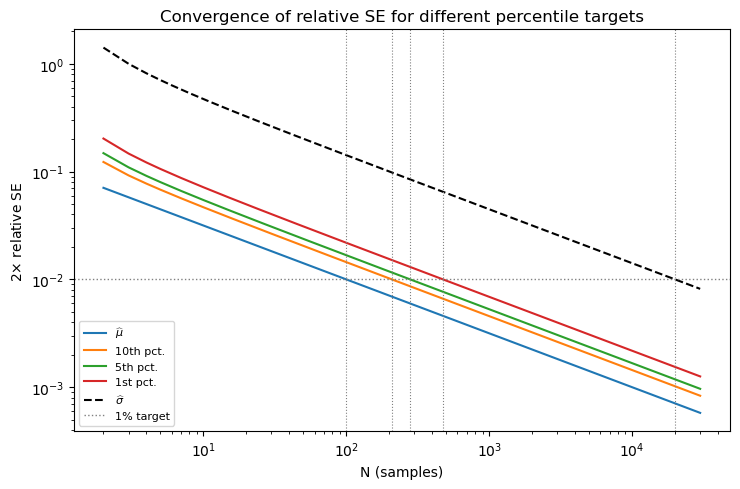

Required N for 2*relSE <= 1%, by target:
  $\widehat\mu$  : N = 100
  10th pct.      : N = 209
  5th pct.       : N = 280
  1st pct.       : N = 476
  std alone      : N = 20001


In [4]:
K_CONF = 2.0        # k=2, the ~95% confidence-level convention used throughout this notebook
TARGET_REL = 0.01    # target: Q_p known to within 1% of its own value


def q_p(z_p):
    """Q_p = mu + z_p*sigma - the closed-form p-th percentile of X_T (and, via A*Q_p, of
    F_peak too)."""
    return MU + z_p * SIGMA


def relse_mean(N):
    """Relative SE of the sample mean: SE(mean)/mu = CoV/sqrt(N) (Ahn & Fessler, Sec. II-A)."""
    return (SIGMA / MU) / np.sqrt(N)


def relse_std(N):
    """Relative SE of the sample std: SE(std)/sigma ~ 1/sqrt(2*(N-1)) (Ahn & Fessler, Sec.
    II-C, eq. 3; valid for N > 10, undefined at N=1 since a sample std needs at least 2 points)."""
    return 1.0 / np.sqrt(2 * (N - 1))


def relse_q_p(N, z_p):
    """Relative SE of Q_p_hat for an arbitrary target z_p, combining the two SEs above in
    quadrature (see the derivation above)."""
    Qp = q_p(z_p)
    w_mu = MU / Qp
    w_sigma = z_p * SIGMA / Qp
    return np.hypot(w_mu * relse_mean(N), w_sigma * relse_std(N))


def required_n(z_p, target_rel=TARGET_REL, k=K_CONF, n_max=200_000):
    """Smallest N with k*relSE(Q_p_hat) <= target_rel, for the given target z_p."""
    n = 3
    while k * relse_q_p(n, z_p) > target_rel and n < n_max:
        n += 1
    return n


def required_n_std(target_rel=TARGET_REL, k=K_CONF, n_max=200_000):
    """Smallest N with k*relSE(std) <= target_rel - the sample size needed to pin down sigma
    itself to the same tolerance, on the same terms as required_n above pins down a
    percentile."""
    n = 3
    while k * relse_std(n) > target_rel and n < n_max:
        n += 1
    return n


# Four percentile targets compared on equal footing: the mean itself (z_p=0, i.e. Q_p=mu) and
# three lower-tail percentiles. Deeper into the tail (more negative z_p) should need a larger
# N, since sigma's weight w_sigma(z_p) grows with |z_p| (see the derivation above).
TARGETS = {r"$\widehat\mu$": 0.0, "10th pct.": Z_P["10%"], "5th pct.": Z_P["5%"], "1st pct.": Z_P["1%"]}

N_grid = np.arange(2, 30_001)
fig, ax = plt.subplots(figsize=(7.5, 5))
for label, z_p in TARGETS.items():
    rel_se = K_CONF * np.array([relse_q_p(n, z_p) for n in N_grid])
    ax.loglog(N_grid, rel_se, label=label)

# The standard deviation's own relative SE, plotted the same way but NOT folded into any
# percentile estimator - this is the cost of pinning down the scatter itself, shown for
# comparison against every percentile curve above.
rel_se_std = K_CONF * np.array([relse_std(n) for n in N_grid])
ax.loglog(N_grid, rel_se_std, color="k", ls="--", label=r"$\widehat\sigma$")

ax.axhline(TARGET_REL, color="gray", ls=":", lw=1, label=f"{TARGET_REL:.0%} target")

required_n_by_target = {label: required_n(z_p) for label, z_p in TARGETS.items()}
for label, n_req in required_n_by_target.items():
    ax.axvline(n_req, color="gray", ls=":", lw=0.8)
n_req_std = required_n_std()
ax.axvline(n_req_std, color="gray", ls=":", lw=0.8)

ax.set_xlabel("N (samples)")
ax.set_ylabel(f"{K_CONF:.0f}" + r"$\times$ relative SE")
ax.set_title("Convergence of relative SE for different percentile targets")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"Required N for {K_CONF:.0f}*relSE <= {TARGET_REL:.0%}, by target:")
for label, n_req in required_n_by_target.items():
    print(f"  {label:15s}: N = {n_req}")
print(f"  {'std alone':15s}: N = {n_req_std}")


**Reading the result.** The plot above makes the cost of resolving the tail explicit: the
mean's curve ($z_p=0$) needs the fewest samples to hit the 1% target, and each deeper
percentile &ndash; 10th, then 5th, then 1st &ndash; needs more, because a deeper tail target has a
larger $|z_p|$, which hands $\widehat\sigma$'s harder-to-pin-down relative error a bigger
weight in the quadrature sum derived above. The dashed $\widehat\sigma$ curve sits above every
percentile curve and only crosses the 1% target line at $N\approx20{,}001$. That is the payoff of targeting one percentile rather than the whole scatter: $\widehat{Q_p}$ blends the cheap-to-pin-down mean with the
expensive-to-pin-down std, weighted by how much of $Q_p$'s own value each one contributes,
while resolving $\sigma$ itself to the same tolerance would, in effect, pin down *every*
percentile at once &ndash; however increasing dramatically the number of samples needed.

**This notebook commits to the 5th percentile, $Q_{5\%}$, as its target to characterize the tail of the input (and output) distribution.** It sits deep enough into the tail to matter for the "worst-case, not typical" framing motivated earlier, without needing the very large $N$ the 1st percentile (or the std itself) would demand. That choice gives $N=280$.

**Two things worth keeping in mind about this choice, before moving on.** First, both numbers
&ndash; the 1% tolerance and the 5th percentile &ndash; are illustrative, not derived from anything
more fundamental. A real study would size them from engineering judgement and, often,
regulatory or industry codes rather than analyst convenience: the composites industry, for
instance, works with **A-basis** and **B-basis** design allowables, defined as the 1st and 10th
percentile respectively (each itself estimated with 95% confidence, see [Catalanotti, 2022](https://doi.org/10.1016/j.compositesa.2022.107238)). Second, this whole a-priori derivation of $N$ only exists because a closed form for $F_{peak}$'s distribution is available in the first
place &ndash; a genuine special case, not the general situation. Exploiting it here is a deliberate
choice: it lets this notebook introduce standard error, confidence intervals, and quadrature combination on concrete, checkable numbers, and it means the sample size can
simply be fixed once and used, rather than having to *monitor convergence* as samples are added
one batch at a time and stop once the estimate has stabilized &ndash; which is what a general
problem, with no closed form to lean on, would actually require.


In [5]:
N = required_n_by_target["5th pct."]  # this notebook's committed target


### Does an actual random sample deliver this?

$N=280$ is what the theory says is needed for the *typical* behavior of the sampling
procedure &ndash; it says nothing about how one particular, actually-drawn sequence behaves. The
cell below draws $N$ samples from three candidate seeds (2, 16, 90) and checks each one
directly against the $\pm1\%$ target on $\widehat{Q_{5\%}}$ at 95% confidence interval.


In [6]:
CANDIDATE_SEEDS = [2, 16, 90]
Z_5 = Z_P["5%"]
samples = {seed: np.random.default_rng(seed).normal(MU, SIGMA, N) for seed in CANDIDATE_SEEDS}

TARGET_Q5 = q_p(Z_5)  # the true, closed-form 5th percentile of X_T

print(f"{'seed':>6s}{'mean_hat':>12s}{'std_hat':>12s}{'Q5%_hat':>12s}{'Q5% err':>12s}")
for seed in CANDIDATE_SEEDS:
    s = samples[seed]
    m, sd = s.mean(), s.std(ddof=1)
    q5_hat = m + Z_5 * sd
    err = (q5_hat - TARGET_Q5) / TARGET_Q5
    print(f"{seed:6d}{m:12.3f}{sd:12.3f}{q5_hat:12.3f}{err:+12.4%}")
    assert err <= TARGET_REL, f"seed {seed}'s Q5%_hat missed the {TARGET_REL:.0%} target at N={N}"


  seed    mean_hat     std_hat     Q5%_hat     Q5% err
     2     988.253      49.457     906.903    -0.1846%
    16     990.564      49.801     908.648    +0.0075%
    90     993.245      50.832     909.635    +0.1161%


All 3 candidates seeds land within the $\pm1\%$ target on $\widehat{Q_{5\%}}$ at $N=280$.

How did each seed actually *get to* that final, converged answer? The cell below tracks the
running mean, running std, and running $Q_{5\%}$ plug-in for each candidate seed as more of
its already-drawn $N$ samples are used, and overlays a $\pm2SE(n)$ band around each true value
(representing the band where we expect the estimate to fall with 95% confidence) together with the actual
$\pm1\%$ target on $\widehat{Q_{5\%}}$ the sample size was sized against.


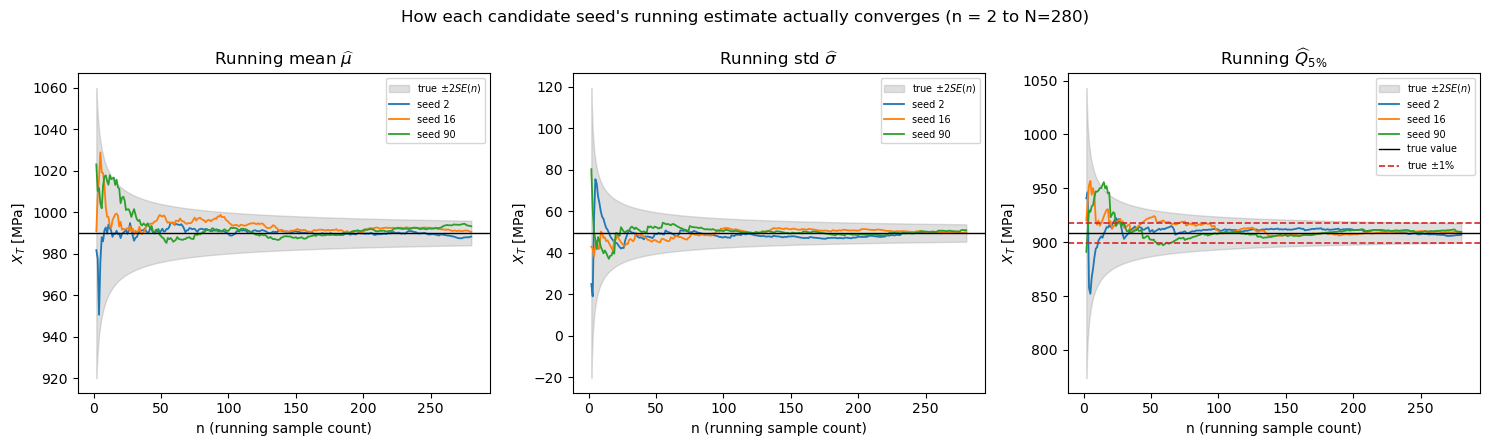

Running Q5% settling point (first n after which the +-1% band is never left again):
  seed 2: settles by n=28 (of N=280)
  seed 16: settles by n=76 (of N=280)
  seed 90: settles by n=65 (of N=280)


In [7]:
n_range = np.arange(2, N + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
se_mean_n = SIGMA / np.sqrt(n_range)
se_std_n = SIGMA / np.sqrt(2 * (n_range - 1))
se_q5_n = np.array([relse_q_p(n, Z_5) for n in n_range]) * TARGET_Q5

axes[0].fill_between(n_range, MU - 2 * se_mean_n, MU + 2 * se_mean_n, color="gray", alpha=0.25, label=r"true $\pm2SE(n)$")
axes[1].fill_between(n_range, SIGMA - 2 * se_std_n, SIGMA + 2 * se_std_n, color="gray", alpha=0.25, label=r"true $\pm2SE(n)$")
axes[2].fill_between(n_range, TARGET_Q5 - 2 * se_q5_n, TARGET_Q5 + 2 * se_q5_n, color="gray", alpha=0.25, label=r"true $\pm2SE(n)$")

for seed in CANDIDATE_SEEDS:
    s = samples[seed]
    running_mean = np.cumsum(s)[n_range - 1] / n_range   # cumsum(s)[n-1] = sum of the first n draws
    running_std = np.array([s[:n].std(ddof=1) for n in n_range])
    running_q5 = running_mean + Z_5 * running_std
    axes[0].plot(n_range, running_mean, lw=1.3, label=f"seed {seed}")
    axes[1].plot(n_range, running_std, lw=1.3, label=f"seed {seed}")
    axes[2].plot(n_range, running_q5, lw=1.3, label=f"seed {seed}")

axes[0].axhline(MU, color="k", lw=1)
axes[1].axhline(SIGMA, color="k", lw=1)
axes[2].axhline(TARGET_Q5, color="k", lw=1, label="true value")

# The actual +-1% target this notebook sizes N against, shown on the Q5% panel only.
axes[2].axhline(TARGET_Q5 * (1 - TARGET_REL), color="C3", ls="--", lw=1.2, label=f"true $\\pm${TARGET_REL:.0%}")
axes[2].axhline(TARGET_Q5 * (1 + TARGET_REL), color="C3", ls="--", lw=1.2)

for ax, title in zip(axes, ["Running mean $\\widehat\\mu$", "Running std $\\widehat\\sigma$", "Running $\\widehat{Q}_{5\\%}$"]):
    ax.set_xlabel("n (running sample count)")
    ax.set_ylabel("$X_T$ [MPa]")
    ax.set_title(title)
    ax.legend(fontsize=7)

fig.suptitle(f"How each candidate seed's running estimate actually converges (n = 2 to N={N})")
fig.tight_layout()
plt.show()

# For each seed, the smallest n after which the running Q5% estimate NEVER again strays
# outside the +-1% target band - i.e. where it settles for good, not just the first time it
# happens to pass through the band on its way to a later excursion.
print("Running Q5% settling point (first n after which the +-1% band is never left again):")
for seed in CANDIDATE_SEEDS:
    s = samples[seed]
    running_mean = np.cumsum(s)[n_range - 1] / n_range
    running_std = np.array([s[:n].std(ddof=1) for n in n_range])
    running_q5 = running_mean + Z_5 * running_std
    inside = np.abs(running_q5 - TARGET_Q5) / TARGET_Q5 <= TARGET_REL
    outside_idx = np.where(~inside)[0]
    settle_n = n_range[0] if len(outside_idx) == 0 else n_range[min(outside_idx[-1] + 1, len(n_range) - 1)]
    print(f"  seed {seed}: settles by n={settle_n} (of N={N})")


**Reading the convergence plot.** All three curves are within the $\pm2SE(n)$ band for essentially the entire range of $n$, while $\widehat{Q_{5\%}}$ swings outside the $\pm1\%$ target at small $n$, and it remains within the target as $n$ increases, well before the full $N=280$.

We make the arbitrary choice to use **Seed 2** for the rest of this notebook.


In [8]:
# Commit to seed 2 for both Monte Carlo campaigns below
SEED = 2
x_t_campaign = samples[SEED]
assert (x_t_campaign > 0).all(), "Drew a non-physical negative X_T - see the negative-tail caveat earlier."

## Part 3 &ndash; Preparing the campaigns

### Sizing the Static step's displacement budget

With $N=280$ and a committed seed (Part 2), one practical detail needs checking before
spending any Abaqus time: NB1's own baseline run used a single fixed prescribed displacement,
`TARGET_U1=3.0` mm, sized for one point ($X_T=990$ MPa) only. This campaign instead runs
$X_T$ across the whole range seed 2's 280 draws actually cover, so the step has to stay
adequate over that *whole* range, not just the nominal value.

NB1 derived the **full-failure displacement** &ndash; the displacement (measured from the
origin) at which `DAMAGEFT` reaches 1.0 and the fiber-tension stiffness is fully removed &ndash;
from the fracture energy $G_{fT}$ and the strength $X_T$ itself (linear softening, NB1's
energy-based damage-evolution theory):

$$
\delta_f = \frac{2\,G_{fT}}{X_T}.
$$

$\delta_f$ is *inversely* proportional to $X_T$: a **smaller** strength needs a **larger**
displacement to fully soften (the same fracture energy $G_{fT}$, dissipated by a lower peak
stress, needs a longer softening branch to make up the same area under the $\sigma$-$\delta$
curve). At the nominal $X_T=990$ MPa this gives $\delta_f\approx2.61$ mm &ndash; NB1's own
number, and the reason NB1 prescribed $U_1=3.0$ mm: enough to see the whole softening branch
play out at that one value.

This campaign samples $X_T$ as low as the smallest of the 280 draws, so **the binding case is
the smallest sampled $X_T$**, not the nominal value &ndash; the cell below checks it directly, and
sizes `TARGET_U1` from that worst case rather than from NB1's single-point number.

This notebook only ever reads off $F_{peak}$, the force at the *instant* of damage initiation &ndash; which happens far
earlier in the loading history than full failure, so in principle the step could safely stop
right after initiation without ever reaching $\delta_f$. The check below is still worth doing
because it costs nothing extra and keeps every stored run's full history complete (useful if a
later notebook wants $\delta_f$ too, or wants to plot the whole softening branch the way Part
4's cloud plots do below) &ndash; but it is not, strictly, required for the one quantity this
notebook is actually built around.


In [9]:
GfT = 1290.0      # N/mm, fiber-tension fracture energy - literal source value (NB1)


def delta_f(x_t):
    """Full-failure displacement (measured from the origin, per NB1's theory) at a given
    X_T."""
    return 2.0 * GfT / x_t


# The binding case is the SMALLEST X_T actually drawn for this campaign - not the nominal
# value NB1 checked against - since delta_f grows as X_T shrinks.
x_t_min_campaign = float(x_t_campaign.min())
delta_f_nominal = delta_f(MU)
delta_f_worst = delta_f(x_t_min_campaign)
delta_f_worst_ceil = float(np.ceil(delta_f_worst))  # bare minimum: next whole mm above the worst-case need

# The bare minimum above would leave only about 1% margin - workable in principle, but
# uncomfortably tight for an analytical estimate that is itself built on NB1's own
# APPROXIMATED fracture-energy values (see NB1's material table). This campaign affords one
# full extra millimeter of margin beyond that minimum: a larger TARGET_U1 costs only a modest
# number of additional solver increments per run, at essentially no wall-clock penalty, so
# there is no reason not to buy the extra safety margin.
TARGET_U1 = delta_f_worst_ceil + 1.0

print(f"delta_f at nominal X_T={MU:.0f} MPa (NB1's own check):  {delta_f_nominal:.3f} mm")
print(f"Smallest sampled X_T (this campaign):                  {x_t_min_campaign:.2f} MPa")
print(f"delta_f at that smallest X_T (the binding case):       {delta_f_worst:.3f} mm")
print(f"Bare minimum: ceil({delta_f_worst:.3f}) = {delta_f_worst_ceil:.1f} mm "
      f"({(delta_f_worst_ceil - delta_f_worst) / delta_f_worst:.1%} margin - workable but tight)")
print(f"TARGET_U1 = {delta_f_worst_ceil:.1f} + 1.0 = {TARGET_U1:.1f} mm "
      f"(margin: {TARGET_U1 - delta_f_worst:.3f} mm, {(TARGET_U1 - delta_f_worst) / delta_f_worst:.1%} above the need)")


delta_f at nominal X_T=990 MPa (NB1's own check):  2.606 mm
Smallest sampled X_T (this campaign):                  869.15 MPa
delta_f at that smallest X_T (the binding case):       2.968 mm
Bare minimum: ceil(2.968) = 3.0 mm (1.1% margin - workable but tight)
TARGET_U1 = 3.0 + 1.0 = 4.0 mm (margin: 1.032 mm, 34.8% above the need)


As expected, the smallest sampled $X_T$ ($\approx869$ MPa) is indeed the binding case,
needing $\delta_f\approx2.97$ mm &ndash; more than NB1's nominal-point number, exactly because
$\delta_f$ grows as $X_T$ shrinks. `TARGET_U1=4.0` mm (the value both Monte Carlo campaigns in
Part 4 were actually run at) gives about 1.03 mm of margin, roughly 35% above the actual
worst-case need &ndash; comfortable without being wasteful. Geometric nonlinearity changes *how*
the model responds to a given prescribed displacement, not the small-strain displacement
budget used to size the step, so the same `TARGET_U1` is a reasonable starting point for both
`nlgeom` settings.

The Static step's increment settings (`initialInc`, `minInc`, `maxNumInc`) aren't tied to the
absolute scale of $X_T$ the same way `TARGET_U1` is &ndash; they're expressed in normalized step
time (0 to 1, mapped onto displacement 0 to `TARGET_U1` by the default ramp amplitude) rather
than by load or displacement directly &ndash; so they carry over unchanged from NB1's own
already-working settings.

**One more check, applied per-run in Part 4 below**: confirming that `HSNFTCRT` (the
fiber-tension damage-initiation criterion) actually reached approximately 1.0 somewhere in
each run's recorded history. If it didn't, that would mean the step's displacement budget was
wrong for that particular sample &ndash; worth flagging immediately rather than silently trusting
whatever `F_peak` came out.

### The shared script, briefly recalled

A Monte Carlo campaign means running the same model many times, each with a different sampled
$X_T$. NB1 introduces and fully explains `scripts/build_fiber_tension.py` &ndash; the model
geometry, material, boundary conditions, Static step, and how the script's command-line
parameters are parsed (`nlgeom`, `X_T`, `U1`, `out`, all `key=value` tokens). This notebook
doesn't repeat that story &ndash; it just calls the same script NB1 does, with different arguments
each run.

**The two invocations this notebook uses**, one per Monte Carlo campaign in Part 4, both with
the `TARGET_U1=4.0` mm budget just derived above and each campaign's own output filename so a
run can never collide with NB1's own verification runs or the other campaign:

```
python build_fiber_tension.py nlgeom=OFF X_T=<sampled value> U1=4.0 out=fiber_tension_results_mc.json
python build_fiber_tension.py nlgeom=ON  X_T=<sampled value> U1=4.0 out=fiber_tension_results_mc.json
```

Every other line of model-building logic &ndash; material properties, boundary conditions, output
requests &ndash; is identical between the two; only the `nlgeom` flag changes, exactly mirroring
NB1's own Part A / Part B structure.


## Part 4 &ndash; Two Monte Carlo campaigns: `nlgeom=OFF` and `nlgeom=ON`

With the sample size derived (Part 2), the displacement budget checked and the shared script
recalled (Part 3), the campaign itself is: run each of the $N$ sampled $X_T$ values through
Abaqus **twice** &ndash; once with `nlgeom=OFF`, once with `nlgeom=ON` &ndash; and keep the *entire*
$u_1$-$RF_1$ and damage-criterion history from every run.

**One thing has to be said plainly before either campaign runs.** The $N=280$ sizing in Part
2 guarantees the 1% target on $\widehat{Q_{5\%}}$ **only for `nlgeom=OFF`**. That guarantee
rests on $F_{peak}=A\cdot X_T$ being an *exactly linear* map of a *Normal* input &ndash; the two
facts that let $\text{relSE}(\widehat{Q_{5\%}}(F_{peak}))$ equal
$\text{relSE}(\widehat{Q_{5\%}}(X_T))$ in the first place (Part 2). `nlgeom=ON` breaks the
linearity: the same $X_T$ no longer maps to $F_{peak}$ through a constant scale factor, so there
is no guarantee left that $F_{peak}$ has a normal distribution and that $N=280$ delivers 1% precision on `nlgeom=ON`'s own $Q_{5\%}$. This means that we will need to assess the empirical distribution of `nlgeom=ON`'s $F_{peak}$ with care before deciding whether we can reasonably describe it as a Normal distribution, and whether the obtained 5th percentile is trustworthy.

A few design choices worth stating up front:

- **Both campaigns share the same `X_T` draw.** This isolates the effect under study &ndash;
  `nlgeom` &ndash; as the *only* thing that differs between them. The shared draw reuses seed 2.
- **Two campaigns, kept on disk in separate directories/files**: `scripts/mc_runs_off/` +
  `scripts/monte_carlo_summary_off.csv` for `nlgeom=OFF`, and `scripts/mc_runs_on/` +
  `scripts/monte_carlo_summary_on.csv` for `nlgeom=ON`.
- **Every run's full history is saved to its own JSON file** in the relevant campaign's runs
  directory &ndash; the same schema `build_fiber_tension.py` already writes (`u1`, `rf1`,
  `damage_ft`, `damage_mt`, `hsn_ft`, `hsn_mt`), plus the sampled `x_t` itself. This is what
  lets the results section plot every run's force-displacement curve and reconstruct every
  run's peak from its own two-branch fit, like in NB1.
- **A compact summary row is appended to each campaign's summary CSV after every run** &ndash; one
  line per sample, with both the raw peak and the reconstructed peak, so Part 5's aggregate
  statistics don't need to re-open every JSON file just to compute a mean and std.
- **Results persist incrementally and each campaign is independently resumable.** An $N$-run
  campaign takes on the order of an hour and a half; each campaign's own summary CSV is checked
  for already-completed sample indices before each run (with a consistency check against the
  current `X_T` draw), so restarting a partial campaign resumes rather than repeats or
  silently mixes two different campaigns. This also means that once both campaigns have
  completed once, simply re-running this notebook later reads the saved results back rather
  than re-running $2N$ Abaqus jobs.
- **Both campaigns' own total wall-clock time and Abaqus-only solve time are persisted** to a
  small JSON file per campaign (accumulated across any resumed segments), so the cost report
  further below prints real, correct numbers whether the campaigns just ran in this kernel
  session or are being read back from disk on a later rerun.

### Shared campaign infrastructure

The four cells below implement the machinery both campaigns use identically &ndash; only the
`nlgeom` value and the output paths differ between the `nlgeom=OFF` and `nlgeom=ON` calls further down.


**Cell 1 of 4: the reconstruction logic and the resume-safety guard.** This first cell
defines three pieces used by every run of both campaigns:

- `FIELDNAMES` &ndash; the column schema shared by both campaigns' summary CSVs (`monte_carlo_summary_off.csv`
  and `monte_carlo_summary_on.csv`), so the two files are always structured identically.
- `reconstruct_peak(u1, rf1, hsn_ft)` &ndash; NB1's double-linear-fit peak reconstruction, applied
  to one run's recorded history. This is called once per sample inside `run_one_sample`
  below, and its output (`f_peak_recon_n`) is what every "reconstructed" statistic in Part 5
  is built from.
- `already_run_samples` and `check_consistent_or_skip` &ndash; together, these are what make a
  campaign resumable: they read back which sample indices already have a row in the summary
  CSV, and verify each one still matches the *current* `X_T` draw before skipping it. This
  pair is called from inside `run_campaign` (defined two cells below) once per sample, before
  deciding whether to actually launch Abaqus for it.


In [10]:
# ------------------------------------------------------------------------------------------
# Shared infrastructure, used identically by both campaigns below (only the `nlgeom` value
# and the output paths differ between the two calls) - one copy of this logic, not two.
# ------------------------------------------------------------------------------------------
import csv
import json
import subprocess
import sys
import time
from pathlib import Path

# One shared column schema for both campaigns' summary CSVs: the sampled input, both
# definitions of the peak force (raw vs. reconstructed), the HSNFTCRT budget check, and the
# wall-clock time this one sample took to run.
FIELDNAMES = [
    "sample_index", "x_t_mpa",
    "f_peak_raw_n", "u1_peak_raw_mm",       # raw: simply the max of the recorded RF1/u1 arrays
    "f_peak_recon_n", "u1_peak_recon_mm",   # reconstructed: NB1's double-linear-fit intersection (see Part 5)
    "hsnftcrt_max", "hsnftcrt_ok", "run_seconds",
]


def reconstruct_peak(u1, rf1, hsn_ft):
    """Reconstruct the true peak by intersecting the elastic and softening branches either
    side of damage initiation - NB1's fix for the solver's coarse increment
    spacing right around the peak (see NB1's "Reconstructing the peak" section). Works
    identically for nlgeom=OFF and nlgeom=ON runs; only the recorded u1/rf1/hsn_ft values
    themselves differ between the two.

    Returns (u1_peak, f_peak), or (nan, nan) if this run's recorded history doesn't have at
    least two increments on each side of initiation to fit a line through (should not happen
    for a well-resolved run, but guarded here rather than letting the campaign loop crash on
    a single bad sample).
    """
    # hsn_ft is the HSNFTCRT history (the fiber-tension Hashin criterion, 0 before damage,
    # reaching 1.0 the instant damage initiates); argmax on a boolean array finds the FIRST
    # True, i.e. the first increment where the criterion actually reached 1.0.
    init_idx = int(np.argmax(hsn_ft >= 1.0))  # first increment where the fiber-tension criterion reached 1.0
    if init_idx < 2 or init_idx + 1 >= len(u1):
        return float("nan"), float("nan")  # not enough elastic or softening points recorded around initiation

    elastic_idx = [init_idx - 2, init_idx - 1]   # two increments immediately before initiation
    softening_idx = [init_idx, init_idx + 1]     # two increments immediately after (and including) initiation

    # A line through exactly two points has one unique slope and intercept - direct
    # closed-form arithmetic here; a general-purpose solver (np.polyfit, np.linalg.lstsq)
    # would work too, but is unnecessary machinery for an exact two-point fit.
    m_elastic = (rf1[elastic_idx[1]] - rf1[elastic_idx[0]]) / (u1[elastic_idx[1]] - u1[elastic_idx[0]])
    b_elastic = rf1[elastic_idx[0]] - m_elastic * u1[elastic_idx[0]]
    m_softening = (rf1[softening_idx[1]] - rf1[softening_idx[0]]) / (u1[softening_idx[1]] - u1[softening_idx[0]])
    b_softening = rf1[softening_idx[0]] - m_softening * u1[softening_idx[0]]

    # The reconstructed peak is where the two fitted lines cross: setting m_elastic*u+b_elastic
    # = m_softening*u+b_softening and solving for u gives u1_peak below.
    u1_peak = (b_softening - b_elastic) / (m_elastic - m_softening)  # where the two lines meet
    f_peak = m_elastic * u1_peak + b_elastic
    return float(u1_peak), float(f_peak)


def already_run_samples(summary_csv):
    """Map of sample_index -> stored x_t_mpa for every row already written to this campaign's
    summary CSV - the basis for deciding what a resumed/rerun campaign can skip. Returns a
    dict (not just a set of indices) specifically so check_consistent_or_skip below can
    compare the STORED x_t against the CURRENT draw, not just check "has this index run"."""
    if not summary_csv.exists():
        return {}
    with open(summary_csv, newline="") as f:
        return {int(row["sample_index"]): float(row["x_t_mpa"]) for row in csv.DictReader(f)}


def check_consistent_or_skip(i, done, x_t_campaign, summary_csv):
    """If sample i is already in summary_csv, verify it matches the current draw before
    skipping it. A resumed/rerun campaign is only safe to skip rows from if the sampled X_T
    for that index is still the same value it was when the row was written - otherwise a
    changed seed or N would silently mix samples from two different campaigns.
    """
    if i not in done:
        return False  # never run before -> run_campaign will call run_one_sample for it
    stored_x_t = done[i]
    current_x_t = x_t_campaign[i]
    if abs(stored_x_t - current_x_t) > 1e-6 * abs(current_x_t):
        raise RuntimeError(
            f"Sample {i} in {summary_csv} has X_T={stored_x_t:.6f}, but the current campaign "
            f"draw expects X_T={current_x_t:.6f} - the seed or N changed since that "
            f"row was written. Delete {summary_csv} (and its runs directory) to start a fresh "
            f"campaign rather than mixing two."
        )
    return True  # already run, and consistent with the current draw -> safe to skip


**Cell 2 of 4: the single-sample driver.** `run_one_sample(sample_index, x_t, nlgeom, runs_dir, summary_csv)`
is the function that actually launches one Abaqus job: it calls `build_fiber_tension.py` as a
subprocess with the given `X_T` and `nlgeom`, checks for the declared output *file* rather
than trusting the subprocess's return code (a genuine quirk of this Abaqus install, explained
where NB1 first hits it), saves the run's full history to its own JSON file under `runs_dir`,
and appends one row &ndash; raw peak, reconstructed peak (via `reconstruct_peak` from the cell
above), and the `HSNFTCRT` check &ndash; to `summary_csv`. This is the function `run_campaign`
(next cell) calls once per still-missing sample index.


In [11]:
def run_one_sample(sample_index, x_t, nlgeom, runs_dir, summary_csv):
    """Run the shared build_fiber_tension.py for one X_T under the given nlgeom setting,
    save its full history under runs_dir, and append a summary row (raw + reconstructed
    peak) to summary_csv. Identical logic for both campaigns - only `nlgeom` and the two
    output-path arguments differ between the `nlgeom=OFF` and `nlgeom=ON` calls made further below.
    """
    # A stale results file from a DIFFERENT prior run (e.g. NB1's own verification runs, or a
    # crashed previous sample) can't be allowed to masquerade as this sample's success below.
    results_path = Path("../scripts/fiber_tension_results_mc.json")
    results_path.unlink(missing_ok=True)

    t0 = time.perf_counter()
    result = subprocess.run(
        [sys.executable, "build_fiber_tension.py", f"nlgeom={nlgeom}", f"X_T={x_t:.6f}",
         f"U1={TARGET_U1}", "out=fiber_tension_results_mc.json"],
        cwd="../scripts",       # build_fiber_tension.py expects to run from scripts/, same as NB1
        capture_output=True,    # captured (not streamed) so only the error path below prints it
        text=True,
    )
    elapsed = time.perf_counter() - t0

    # result.returncode is NOT a reliable success signal here - abqpy's `from abaqus import *`
    # unconditionally calls sys.exit(0) once it hands the script to real Abaqus, regardless of
    # whether that Abaqus run itself succeeded. The only trustworthy signal is whether the
    # script actually produced its declared output file.
    if not results_path.exists():
        raise RuntimeError(
            f"Sample {sample_index} (X_T={x_t:.2f}, nlgeom={nlgeom}) did not produce results - "
            f"stdout:\n{result.stdout}\nstderr:\n{result.stderr}"
        )

    with open(results_path) as f:
        data = json.load(f)

    # Save this run's full history under its own name, so the results section can later plot
    # every run's force-displacement curve and re-derive its reconstructed peak if needed.
    run_path = runs_dir / f"run_{sample_index:03d}.json"
    with open(run_path, "w") as f:
        json.dump(data, f)

    # Pull out just the three arrays reconstruct_peak (and the raw-peak calculation below)
    # actually need, as plain numpy arrays rather than the raw JSON lists.
    u1 = np.array(data["u1"])
    rf1 = np.array(data["rf1"])
    hsn_ft = np.array(data["hsn_ft"])

    f_peak_raw = float(rf1.max())                  # the naive definition of peak force: simply the max recorded RF1
    u1_peak_raw = float(u1[int(rf1.argmax())])      # the displacement at which that raw maximum occurred
    hsn_max = float(hsn_ft.max())
    hsn_ok = hsn_max >= 0.99  # confirms the step's displacement budget was adequate for this sample

    u1_peak_recon, f_peak_recon = reconstruct_peak(u1, rf1, hsn_ft)

    # Append one row for this sample. write_header only fires on the very first sample of a
    # brand-new campaign (summary_csv doesn't exist yet); every later call, including on a
    # resumed campaign in a fresh kernel session, appends without repeating the header.
    write_header = not summary_csv.exists()
    with open(summary_csv, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        if write_header:
            writer.writeheader()
        writer.writerow({
            "sample_index": sample_index,
            "x_t_mpa": x_t,
            "f_peak_raw_n": f_peak_raw,
            "u1_peak_raw_mm": u1_peak_raw,
            "f_peak_recon_n": f_peak_recon,
            "u1_peak_recon_mm": u1_peak_recon,
            "hsnftcrt_max": hsn_max,
            "hsnftcrt_ok": hsn_ok,
            "run_seconds": elapsed,
        })

    return f_peak_raw, f_peak_recon, hsn_max, hsn_ok, elapsed


**Cell 3 of 4: the resumable campaign loop and its cost report.** This cell defines four
functions:

- `load_timing` / `save_timing` &ndash; read and write a small JSON file (`mc_timing_off.json` /
  `mc_timing_on.json`) that accumulates each campaign's total wall-clock time across however
  many separate sessions it took to complete.
- `run_campaign(nlgeom, x_t_campaign, runs_dir, summary_csv, timing_json)` &ndash; the actual
  campaign driver, called once per `nlgeom` setting further below (`run_campaign("OFF", ...)`
  and `run_campaign("ON", ...)`). It loops over every sample index, skips any already
  completed (via `check_consistent_or_skip` from Cell 1), calls `run_one_sample` for the
  rest, and updates the timing file.
- `report_campaign_cost(label, summary_csv, timing_json)` &ndash; prints each campaign's total
  wall-clock time, Abaqus-only solve time, and per-run statistics, reading everything back
  from disk so it reports correctly whether the campaign just ran in this kernel session or
  is being read back from a completed prior run.


In [12]:
def load_timing(timing_json):
    """Read this campaign's persisted total wall-clock time, or a zeroed record if this
    campaign has never been (even partially) run before."""
    if timing_json.exists():
        with open(timing_json) as f:
            return json.load(f)
    return {"wall_clock_seconds": 0.0, "n_runs_completed": 0}


def save_timing(timing_json, record):
    with open(timing_json, "w") as f:
        json.dump(record, f, indent=2)


def run_campaign(nlgeom, x_t_campaign, runs_dir, summary_csv, timing_json):
    """Run every sample of x_t_campaign through build_fiber_tension.py with the given nlgeom
    setting, skipping any sample already present (and verified consistent) in summary_csv -
    so re-running this cell after an interruption, or simply re-running the whole notebook
    on a later day, resumes/reuses rather than repeating completed runs.

    The wall-clock time of only the samples actually run in THIS call is added to whatever
    total was already persisted in timing_json (0 the first time), so a campaign resumed
    across several sessions still ends up with a correct grand total - and a pure rerun,
    where every sample is already done, leaves the persisted total untouched instead of
    padding it with negligible loop/bookkeeping overhead.
    """
    runs_dir.mkdir(exist_ok=True)
    done = already_run_samples(summary_csv)   # {sample_index: stored x_t}, empty dict for a brand-new campaign
    timing = load_timing(timing_json)

    n_new = 0                                  # counts only the samples actually run THIS call, not the total
    segment_start = time.perf_counter()
    for i in range(len(x_t_campaign)):
        if check_consistent_or_skip(i, done, x_t_campaign, summary_csv):
            continue  # already completed (and verified consistent) in a previous run of this cell/notebook

        x_t = x_t_campaign[i]
        f_peak_raw, f_peak_recon, hsn_max, hsn_ok, elapsed = run_one_sample(
            i, x_t, nlgeom, runs_dir, summary_csv)
        n_new += 1

        if not hsn_ok:
            print(f"[nlgeom={nlgeom}][{i}] WARNING: HSNFTCRT_max={hsn_max:.3f} did not reach "
                  f"~1.0 - investigate this sample.")
        # Print progress every 20th sample (plus always the last one), rather than every
        # single run - enough to see the campaign is progressing without flooding the output.
        if i % 20 == 0 or i == len(x_t_campaign) - 1:
            print(f"[nlgeom={nlgeom}][{i + 1}/{len(x_t_campaign)}] X_T={x_t:7.2f} MPa -> "
                  f"F_peak_raw={f_peak_raw:8.2f} N, F_peak_recon={f_peak_recon:8.2f} N  ({elapsed:.1f}s)")

    segment_seconds = time.perf_counter() - segment_start

    if n_new > 0:
        # A genuine new segment of work happened this call: add its wall-clock time to
        # whatever total was already persisted (0 for a brand-new campaign).
        timing["wall_clock_seconds"] = timing.get("wall_clock_seconds", 0.0) + segment_seconds
        timing["n_runs_completed"] = len(done) + n_new
        save_timing(timing_json, timing)
        print(f"\n[nlgeom={nlgeom}] Ran {n_new} new sample(s) this segment in {segment_seconds:.0f}s "
              f"- cumulative wall-clock persisted for this campaign: {timing['wall_clock_seconds']:.0f}s.")
    else:
        # Every sample was already done -> nothing was launched this call, so the persisted
        # timing total is left untouched rather than padded with negligible loop overhead.
        print(f"\n[nlgeom={nlgeom}] All {len(x_t_campaign)} samples already completed - nothing new to "
              f"run. Reading results back from {summary_csv} instead (see the cost report below).")


def report_campaign_cost(label, summary_csv, timing_json):
    """Print this campaign's total wall-clock time and Abaqus-only solve time. Reads both
    numbers back from disk (the summary CSV's own run_seconds column, and the persisted
    timing JSON) rather than from any in-memory state - so this cell prints correct numbers
    whether the campaign was just run in this kernel session, or the whole notebook was
    restarted and this cell is simply reading back a previously-completed campaign's results.
    """
    with open(summary_csv, newline="") as f:
        rows = list(csv.DictReader(f))
    run_seconds_all = np.array([float(r["run_seconds"]) for r in rows])
    abaqus_seconds = float(run_seconds_all.sum())  # Abaqus-only: sum of every individual run's own solve time

    timing = load_timing(timing_json)
    wall_clock_seconds = timing.get("wall_clock_seconds", float("nan"))

    print(f"--- {label} campaign cost ({len(rows)} completed runs) ---")
    print(f"Total wall-clock time:  {wall_clock_seconds:8.0f} s  ({wall_clock_seconds / 3600:.2f} h)")
    print(f"Abaqus-only time:       {abaqus_seconds:8.0f} s  ({abaqus_seconds / 3600:.2f} h)  "
          f"- sum of every run's own solve time")
    if not np.isnan(wall_clock_seconds):
        # The difference between the two totals above is Python-side bookkeeping (subprocess
        # launch, file I/O), NOT part of Abaqus's own solve time.
        overhead = wall_clock_seconds - abaqus_seconds
        print(f"Python-side overhead:   {overhead:8.0f} s  - subprocess bookkeeping, file I/O, not Abaqus itself")
    print(f"Per-run solve time:     mean={run_seconds_all.mean():.1f}s, std={run_seconds_all.std(ddof=1):.1f}s, "
          f"min={run_seconds_all.min():.1f}s, max={run_seconds_all.max():.1f}s")


**Cell 4 of 4: the nominal reference run and the cloud plot.** The last two functions are
used purely for visualization, not for any of Part 5's statistics:

- `ensure_nominal_run(nlgeom, nominal_json)` &ndash; runs one dedicated Abaqus job at exactly
  $X_T=\mu$ (not one of the campaign's `N` sampled points), skipping the Abaqus call
  entirely if that campaign's nominal run already exists on disk. This gives a single
  reference curve to plot the whole sampled cloud against.
- `plot_force_displacement_cloud(summary_csv, runs_dir, nominal_data, nlgeom, color)` &ndash; plots
  every sampled run's full force-displacement curve as a faint, semi-transparent line (so
  many overlapping curves read as a density band), with the nominal curve from
  `ensure_nominal_run` drawn on top in black.

Both are called once per campaign further below, right after that campaign's Abaqus runs
complete.


In [13]:
def ensure_nominal_run(nlgeom, nominal_json):
    """A dedicated run at exactly X_T=mu, for a single reference curve to plot the whole
    Monte Carlo cloud against (none of the N sampled X_T values lands exactly on mu).
    This is NOT one of the campaign's N samples - it doesn't feed into any of Part
    5's statistics, only into the illustrative plot right below. Skips the Abaqus call
    entirely if this campaign's nominal run already exists on disk.
    """
    if nominal_json.exists():
        print(f"Nominal nlgeom={nlgeom} run already exists at {nominal_json}, skipping.")
        with open(nominal_json) as f:
            return json.load(f)

    # Same stale-file guard as run_one_sample above: a leftover results file from a different
    # run cannot be mistaken for this nominal run's own output.
    results_path = Path("../scripts/fiber_tension_results_mc.json")
    results_path.unlink(missing_ok=True)

    t0 = time.perf_counter()
    result = subprocess.run(
        [sys.executable, "build_fiber_tension.py", f"nlgeom={nlgeom}", f"X_T={MU:.6f}",
         f"U1={TARGET_U1}", "out=fiber_tension_results_mc.json"],
        cwd="../scripts",
        capture_output=True,
        text=True,
    )
    elapsed = time.perf_counter() - t0

    if not results_path.exists():
        raise RuntimeError(
            f"Nominal nlgeom={nlgeom} run (X_T={MU}) did not produce results - "
            f"stdout:\n{result.stdout}\nstderr:\n{result.stderr}"
        )

    with open(results_path) as f:
        nominal_data = json.load(f)
    with open(nominal_json, "w") as f:
        json.dump(nominal_data, f)   # persisted so a later rerun of the notebook skips the Abaqus call above entirely

    print(f"Nominal nlgeom={nlgeom} run (X_T={MU} MPa) completed in {elapsed:.1f}s -> saved to {nominal_json}")
    return nominal_data


def plot_force_displacement_cloud(summary_csv, runs_dir, nominal_data, nlgeom, color):
    """Every sampled run's full force-displacement curve, shaded together (low alpha + thin
    line so many overlapping curves read as a density/band rather than as individually
    legible lines), with the single nominal (X_T=mu) curve drawn on top in black."""
    with open(summary_csv, newline="") as f:
        summary_rows = list(csv.DictReader(f))
    n_run = len(summary_rows)

    fig, ax = plt.subplots(figsize=(8, 5))
    # Re-open each sampled run's own history file (saved by run_one_sample above) to get its
    # full u1/rf1 curve, not just the summary CSV's single peak-force value.
    for row in summary_rows:
        i = int(row["sample_index"])
        with open(runs_dir / f"run_{i:03d}.json") as f:
            run_data = json.load(f)
        ax.plot(run_data["u1"], run_data["rf1"], color=color, lw=0.6, alpha=0.15)

    ax.plot(nominal_data["u1"], nominal_data["rf1"], color="k", lw=2,
            label=f"nominal ($X_T=\\mu={MU:.0f}$ MPa)")
    ax.plot([], [], color=color, lw=2, alpha=0.5, label=f"sampled runs (n={n_run})")  # solid proxy handle for the legend
    ax.set_xlabel("$U_1$ at loaded edge [mm]")
    ax.set_ylabel("Reaction force, $RF_1$ [N]")
    ax.set_title(f"Force-displacement response (nlgeom={nlgeom}): nominal vs. the full Monte Carlo campaign")
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()


### Campaign A &ndash; `nlgeom=OFF`

Runs the shared script with geometric nonlinearity switched off, exactly mirroring NB1's
Part A. Since this campaign's element formulation matches the small-strain analytical
predictions' own assumptions, its **reconstructed** peak forces should recover the analytical
$\mathcal{N}(A\mu, A\sigma)$ prediction closely &ndash; any remaining gap here can only be the
solver's discretization (fixed by reconstruction) or ordinary Monte Carlo sampling
noise.

This step takes a while: `N` Abaqus runs, each dominated by license/kernel
startup overhead rather than the solve itself (see the per-run timing NB1 already measured).
Re-running this cell after an interruption resumes from wherever it left off, and re-running
the whole notebook after this campaign has completed once reads its results back from disk
instead of re-running any Abaqus jobs (see the design notes above).


In [14]:
# This campaign's own directory, summary CSV, and timing file - kept completely separate
# from the nlgeom=ON campaign below so the two can never be mixed or accidentally overwritten.
RUNS_DIR_OFF = Path("../scripts/mc_runs_off")
SUMMARY_CSV_OFF = Path("../scripts/monte_carlo_summary_off.csv")
TIMING_JSON_OFF = Path("../scripts/mc_timing_off.json")

run_campaign("OFF", x_t_campaign, RUNS_DIR_OFF, SUMMARY_CSV_OFF, TIMING_JSON_OFF)



[nlgeom=OFF] All 280 samples already completed - nothing new to run. Reading results back from ..\scripts\monte_carlo_summary_off.csv instead (see the cost report below).


With the campaign either just completed or read back from a previous run, the cell below
prints its total cost: wall-clock time and Abaqus-only solve time, both persisted to disk so
this reports correctly on a rerun too (see the design notes above).


In [15]:
report_campaign_cost("nlgeom=OFF", SUMMARY_CSV_OFF, TIMING_JSON_OFF)


--- nlgeom=OFF campaign cost (280 completed runs) ---
Total wall-clock time:      5476 s  (1.52 h)
Abaqus-only time:           5475 s  (1.52 h)  - sum of every run's own solve time
Python-side overhead:          1 s  - subprocess bookkeeping, file I/O, not Abaqus itself
Per-run solve time:     mean=19.6s, std=1.1s, min=18.9s, max=28.1s


Most of the wall-clock time above is Abaqus itself (license checkout, kernel startup, and the
solve), with only a small Python-side overhead for subprocess bookkeeping and file I/O &ndash; the
same balance NB1 already measured for a single run, now summed over the whole campaign.


To see this campaign's results as more than a table of numbers, the cell below runs one more,
dedicated Abaqus job at exactly $X_T=\mu$ (the "nominal" run) and plots every sampled run's full
force-displacement curve underneath it, so the whole Monte Carlo cloud is visible at once.


Nominal nlgeom=OFF run already exists at ..\scripts\mc_runs_off\run_nominal_off.json, skipping.


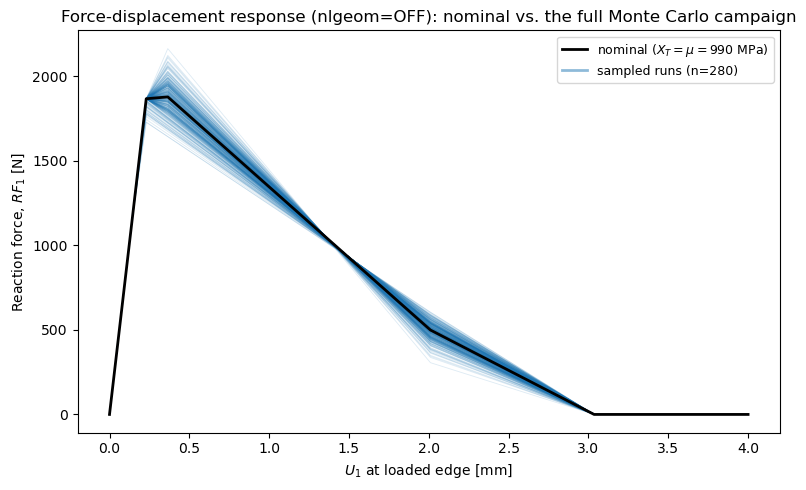

In [16]:
NOMINAL_JSON_OFF = RUNS_DIR_OFF / "run_nominal_off.json"
nominal_data_off = ensure_nominal_run("OFF", NOMINAL_JSON_OFF)
plot_force_displacement_cloud(SUMMARY_CSV_OFF, RUNS_DIR_OFF, nominal_data_off, "OFF", color="C0")


The shaded band of sampled curves fans out around the black nominal curve, wider the further
past the peak each run gets &ndash; consistent with $X_T$'s own scatter propagating through into
both where the peak sits and how the softening branch unfolds afterward. Part 5 turns this
qualitative picture into the actual verified statistics.


### Campaign B &ndash; `nlgeom=ON`

The same `N` samples of $X_T$, the same script, the same `TARGET_U1=4.0` mm
budget &ndash; only `nlgeom` changes, from `nlgeom=OFF` to `nlgeom=ON`, exactly mirroring NB1's Part B.


In [17]:
# This campaign's own directory, summary CSV, and timing file - separate from Campaign A's,
# same rationale as before.
RUNS_DIR_ON = Path("../scripts/mc_runs_on")
SUMMARY_CSV_ON = Path("../scripts/monte_carlo_summary_on.csv")
TIMING_JSON_ON = Path("../scripts/mc_timing_on.json")

run_campaign("ON", x_t_campaign, RUNS_DIR_ON, SUMMARY_CSV_ON, TIMING_JSON_ON)



[nlgeom=ON] All 280 samples already completed - nothing new to run. Reading results back from ..\scripts\monte_carlo_summary_on.csv instead (see the cost report below).


Same cost report as Campaign A, for this campaign.


In [18]:
report_campaign_cost("nlgeom=ON", SUMMARY_CSV_ON, TIMING_JSON_ON)


--- nlgeom=ON campaign cost (280 completed runs) ---
Total wall-clock time:      5475 s  (1.52 h)
Abaqus-only time:           5475 s  (1.52 h)  - sum of every run's own solve time
Python-side overhead:          1 s  - subprocess bookkeeping, file I/O, not Abaqus itself
Per-run solve time:     mean=19.6s, std=1.0s, min=18.9s, max=28.5s


And, as with Campaign A, the cell below runs Campaign B's own nominal ($X_T=\mu$, `nlgeom=ON`)
reference and plots the full sampled cloud on top of it.


Nominal nlgeom=ON run already exists at ..\scripts\mc_runs_on\run_nominal_on.json, skipping.


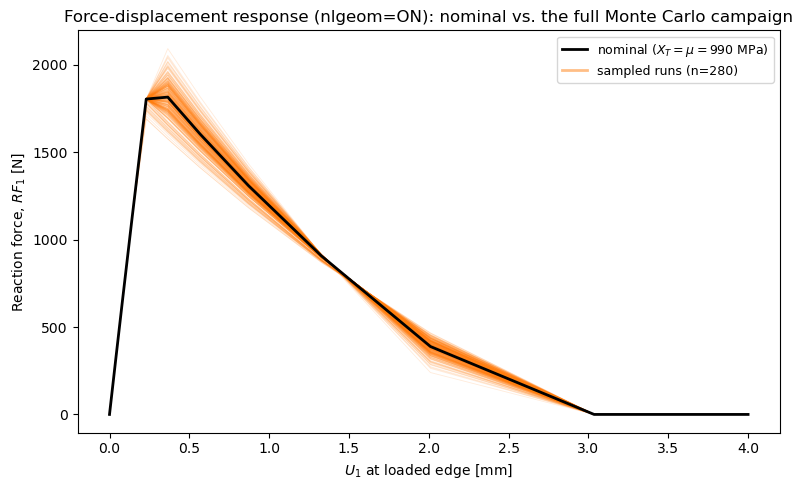

In [19]:
NOMINAL_JSON_ON = RUNS_DIR_ON / "run_nominal_on.json"
nominal_data_on = ensure_nominal_run("ON", NOMINAL_JSON_ON)
plot_force_displacement_cloud(SUMMARY_CSV_ON, RUNS_DIR_ON, nominal_data_on, "ON", color="C1")


With both campaigns now complete &ndash; Campaign A's small-strain results and Campaign B's
`nlgeom=ON` results, run on the identical `X_T` draw &ndash; Part 5 checks each one against the
analytical prediction, and then checks the two against each other directly.


## Part 5 &ndash; Results

Both campaigns are read **separately** below, because `nlgeom=OFF` and `nlgeom=ON` answer two
different questions:

- **`nlgeom=OFF`** is the pipeline-verification campaign. Its input-output map is exactly
  linear, so its output is provably Normal and every one of its statistics has a known
  closed-form answer to check against (Part 1). Any gap between this campaign's results and
  that closed form can only be ordinary Monte Carlo sampling noise (sized by Part 2's own SE
  formulas) or the solver's discretization &ndash; not a genuine physical effect. This is where
  the pipeline itself &ndash; Abaqus, the peak reconstruction, the sample size &ndash; gets checked.
- **`nlgeom=ON`** is the campaign this notebook is actually building toward: a case with **no
  closed-form answer to check against**. There is no guarantee `nlgeom=ON`'s output still has a Normal distribution: without it, mean and std no longer
  determine the tail, and a percentile would have to be read off the sample's own order
  statistics instead. Before using the same two-parameter shortcut for `nlgeom=ON`, its
  distribution has to be examined on its own terms &ndash; the histogram shape, and the pointwise
  $X_T\to F_{peak}$ relationship &ndash; to judge whether that shortcut is still defensible.

For both campaigns, the same two-step logic applies to the peak force itself: the **raw** peak
(the simple maximum of each run's recorded `RF1` array) reads low because of the solver's
coarse increment spacing right around the true peak (NB1's finding, for a single run); the
**reconstructed** peak (NB1's double-linear-fit intersection, already computed per run in Part
4 and stored in `f_peak_recon_n`) corrects for it. Both are checked below so the size of that
correction is visible directly, not just asserted.


The first step is simply loading both campaigns' summary CSVs back into memory and checking,
before anything else, that both completed cleanly.


In [20]:
def load_campaign(summary_csv, label):
    """Load one campaign's summary CSV into plain numpy arrays, and flag anything worth
    investigating before trusting the data (incomplete campaign, HSNFTCRT budget failures,
    failed peak reconstructions)."""
    with open(summary_csv, newline="") as f:
        rows = list(csv.DictReader(f))

    x_t = np.array([float(r["x_t_mpa"]) for r in rows])
    f_peak_raw = np.array([float(r["f_peak_raw_n"]) for r in rows])
    f_peak_recon = np.array([float(r["f_peak_recon_n"]) for r in rows])
    hsn_ok = np.array([r["hsnftcrt_ok"] == "True" for r in rows])

    n_run = len(rows)
    print(f"[{label}] Loaded {n_run} completed runs (planned N={N}).")
    if n_run < N:
        print(f"[{label}] WARNING: only {n_run} of the planned {N} runs have completed - "
              f"the analysis below reflects those {n_run} points only.")
    if not hsn_ok.all():
        n_bad = int((~hsn_ok).sum())
        print(f"[{label}] WARNING: {n_bad} run(s) did not reach HSNFTCRT~=1.0 - investigate before trusting this data.")
    n_recon_failed = int(np.isnan(f_peak_recon).sum())
    if n_recon_failed:
        print(f"[{label}] WARNING: {n_recon_failed} run(s) could not be reconstructed (too few recorded "
              f"increments around initiation) - excluded from this campaign's reconstructed-peak statistics.")

    return {"x_t": x_t, "f_peak_raw": f_peak_raw, "f_peak_recon": f_peak_recon,
            "hsn_ok": hsn_ok, "n_run": n_run}


off_data = load_campaign(SUMMARY_CSV_OFF, "nlgeom=OFF")
on_data = load_campaign(SUMMARY_CSV_ON, "nlgeom=ON")


[nlgeom=OFF] Loaded 280 completed runs (planned N=280).
[nlgeom=ON] Loaded 280 completed runs (planned N=280).


No warnings above means both campaigns loaded all $N$ planned runs, every run reached
`HSNFTCRT`$\approx1.0$ (the displacement budget from Part 3 held for the whole sampled
range), and every run's peak was successfully reconstructed.


`analytical_mean` and `analytical_std` were already computed in Part 1 and they are reused here. The helper below runs both checks (histogram + pointwise scatter) on
both peak-force definitions (raw + reconstructed) for one campaign at a time, prints the
resulting mean/std statistics, and returns them for reuse further below.


In [21]:
analytical_q5 = f_peak_percentiles["5%"]  # already computed in Part 1; reused throughout Part 5


def analyze_and_plot_campaign(data, label, color):
    """For one campaign's loaded data: print raw-vs-analytical and reconstructed-vs-analytical
    mean/std statistics, and plot both checks (histogram-vs-theoretical-PDF, and pointwise
    scatter-vs-A*X_T) for both peak-force definitions in one 2x2 grid - top row RAW, bottom row
    RECONSTRUCTED, so the effect of NB1's reconstruction is directly visible in the figure, not
    just described in text. Does NOT compute a percentile - see the dedicated Q5% step for each
    campaign further below. Returns a dict of the computed statistics for reuse in the
    nlgeom=OFF-vs-nlgeom=ON comparison further below.
    """
    x_t = data["x_t"]
    f_raw = data["f_peak_raw"]
    f_recon_all = data["f_peak_recon"]
    recon_valid = ~np.isnan(f_recon_all)          # drop any run whose reconstruction failed (NaN)
    x_t_recon = x_t[recon_valid]
    f_recon = f_recon_all[recon_valid]

    mean_raw, std_raw = float(f_raw.mean()), float(f_raw.std(ddof=1))
    mean_recon, std_recon = float(f_recon.mean()), float(f_recon.std(ddof=1))

    print(f"=== {label}: raw peak force ===")
    print(f"Analytical:  mean={analytical_mean:.2f} N   std={analytical_std:.2f} N")
    print(f"Empirical:   mean={mean_raw:.2f} N   std={std_raw:.2f} N   (n={len(f_raw)})")
    print(f"Relative difference: mean {abs(mean_raw - analytical_mean) / analytical_mean:.1%}, "
          f"std {abs(std_raw - analytical_std) / analytical_std:.1%}")
    print(f"\n=== {label}: reconstructed peak force ===")
    print(f"Analytical:  mean={analytical_mean:.2f} N   std={analytical_std:.2f} N")
    print(f"Empirical:   mean={mean_recon:.2f} N   std={std_recon:.2f} N   (n={len(f_recon)})")
    print(f"Relative difference: mean {abs(mean_recon - analytical_mean) / analytical_mean:.1%}, "
          f"std {abs(std_recon - analytical_std) / analytical_std:.1%}")

    n_bins = min(20, max(3, len(f_raw) // 5))
    pad = 3 * analytical_std
    x_grid_f = np.linspace(analytical_mean - pad, analytical_mean + pad, 200)
    x_line = np.linspace(x_t.min(), x_t.max(), 50)

    fig, axes = plt.subplots(2, 2, figsize=(11, 8))

    # Top row: RAW peak force - histogram against the analytical PDF, and the pointwise
    # X_T -> F_peak scatter against the exact map A*X_T.
    axes[0, 0].hist(f_raw, bins=n_bins, density=True, color=color, alpha=0.6, label="empirical (raw)")
    axes[0, 0].plot(x_grid_f, gaussian_pdf(x_grid_f, analytical_mean, analytical_std), "k--", lw=1.5,
                     label=r"analytical $\mathcal{N}(A\mu, A\sigma)$")
    axes[0, 0].set_xlabel("$F_{peak}$ [N]"); axes[0, 0].set_ylabel("Density")
    axes[0, 0].set_title(f"{label}: raw peak vs. analytical distribution")
    axes[0, 0].legend(fontsize=8)

    axes[0, 1].scatter(x_t, f_raw, color=color, s=20, alpha=0.7, label="sampled runs (raw)")
    axes[0, 1].plot(x_line, A * x_line, "k--", lw=1.5, label="$F_{peak}=A\\cdot X_T$")
    axes[0, 1].set_xlabel("$X_T$ [MPa]"); axes[0, 1].set_ylabel("$F_{peak}$ [N]")
    axes[0, 1].set_title(f"{label}: pointwise check (raw)")
    axes[0, 1].legend(fontsize=8)

    # Bottom row: same two checks, RECONSTRUCTED peak force - directly comparable to the top
    # row, so the reconstruction's effect (tighter histogram, tighter pointwise scatter) reads
    # off the figure itself.
    axes[1, 0].hist(f_recon, bins=n_bins, density=True, color=color, alpha=0.6, label="empirical (reconstructed)")
    axes[1, 0].plot(x_grid_f, gaussian_pdf(x_grid_f, analytical_mean, analytical_std), "k--", lw=1.5,
                     label=r"analytical $\mathcal{N}(A\mu, A\sigma)$")
    axes[1, 0].set_xlabel("$F_{peak}$ [N]"); axes[1, 0].set_ylabel("Density")
    axes[1, 0].set_title(f"{label}: reconstructed peak vs. analytical distribution")
    axes[1, 0].legend(fontsize=8)

    axes[1, 1].scatter(x_t_recon, f_recon, color=color, s=20, alpha=0.7, label="sampled runs (reconstructed)")
    axes[1, 1].plot(x_line, A * x_line, "k--", lw=1.5, label="$F_{peak}=A\\cdot X_T$")
    axes[1, 1].set_xlabel("$X_T$ [MPa]"); axes[1, 1].set_ylabel("$F_{peak}$ [N]")
    axes[1, 1].set_title(f"{label}: pointwise check (reconstructed)")
    axes[1, 1].legend(fontsize=8)

    fig.tight_layout()
    plt.show()

    # Pointwise deviation from the analytical map A*X_T, reconstructed peak only - the
    # mechanism behind any aggregate mean/std gap is visible directly in these numbers (see
    # the nlgeom=OFF-vs-nlgeom=ON comparison further below).
    dev_recon = f_recon - A * x_t_recon

    return {
        "mean_raw": mean_raw, "std_raw": std_raw,
        "mean_recon": mean_recon, "std_recon": std_recon,
        "dev_recon_mean": float(dev_recon.mean()), "dev_recon_std": float(dev_recon.std(ddof=1)),
        "n_raw": len(f_raw), "n_recon": len(f_recon),
    }


### `nlgeom=OFF`: checking the pipeline against a known answer

`nlgeom=OFF`'s results are checked against the closed-form analytical prediction first, since
&ndash; if the simulation and reconstruction pipeline is behaving correctly &ndash; they should
recover it directly.


=== nlgeom=OFF: raw peak force ===
Analytical:  mean=1980.00 N   std=99.00 N
Empirical:   mean=1904.41 N   std=69.50 N   (n=280)
Relative difference: mean 3.8%, std 29.8%

=== nlgeom=OFF: reconstructed peak force ===
Analytical:  mean=1980.00 N   std=99.00 N
Empirical:   mean=1976.45 N   std=98.91 N   (n=280)
Relative difference: mean 0.2%, std 0.1%


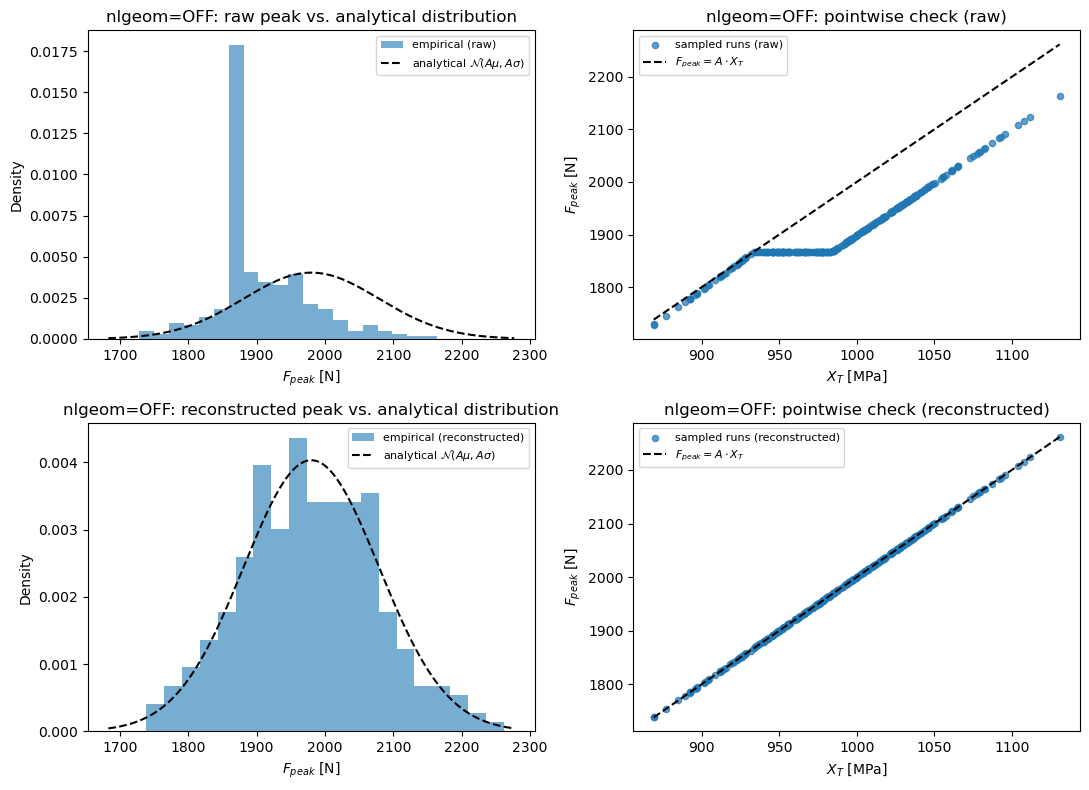

In [22]:
stats_off = analyze_and_plot_campaign(off_data, "nlgeom=OFF", color="C0")


**The raw peak force is a substantially biased statistic.** Raw mean/std sit about 3.8%/29.8%
below the analytical mean/std &ndash; the top row of the figure above shows why: the solver's
increment spacing lands coarsely enough right around the true peak that simply taking the max
of the recorded `RF1` array systematically undershoots, and compresses the *spread* far more
than the average (a discretization artifact NB1 first found for one run, now visible as a
genuine population-level effect). **The reconstruction fixes almost all of it**: reconstructed
mean/std land within about 0.2%/0.1% of the analytical closed form &ndash; the bottom row's
histogram and pointwise scatter both sit tightly on the analytical prediction, exactly as
expected for a campaign whose element formulation matches the small-strain assumptions the
closed form itself relies on.


### One more comparison: against this campaign's own realized sample, not just the population

The check above compares `nlgeom=OFF`'s empirical statistics to the *population* parameters ($\mu$,
$\sigma$) the campaign was meant to sample from. But the campaign draws only `N` *particular*
values of $X_T$ (the same ones shared by *both* campaigns &ndash; Part 4), whose own sample mean
and std won't exactly equal $\mu$ and $\sigma$ &ndash; that gap is expected Monte Carlo sampling
noise, sized by Part 2's own SE formulas, and has nothing to do with whether the *simulation
pipeline* is behaving correctly. Comparing `nlgeom=OFF`'s reconstructed $F_{peak}$ statistics against
$A\cdot(\text{sample mean of }X_T)$ and $A\cdot(\text{sample std of }X_T)$ instead isolates
exactly that distinction: if the pipeline is faithful, its reconstructed $F_{peak}$ should
track the *realized* input sample closely, even if that realized sample itself happens to land
a bit off from $\mu,\sigma$. Since both campaigns share the same input draw, this reference is
computed once below and used for `nlgeom=OFF` here.


In [23]:
# The realized sample's own mean/std (of the actually-drawn X_T values shared by BOTH
# campaigns), as an alternative reference point to the theoretical population mean/std used above.
sample_mean_x_t = float(x_t_campaign.mean())
sample_std_x_t = float(x_t_campaign.std(ddof=1))
sample_ref_mean = A * sample_mean_x_t
sample_ref_std = A * sample_std_x_t

print(f"Sampled X_T (this campaign's actual, shared draw): mean={sample_mean_x_t:.2f} MPa "
      f"({abs(sample_mean_x_t - MU) / MU:.1%} off population mean), "
      f"std={sample_std_x_t:.2f} MPa ({abs(sample_std_x_t - SIGMA) / SIGMA:.1%} off population std)")
print(f"A * sample stats: mean={sample_ref_mean:.2f} N, std={sample_ref_std:.2f} N\n")

print(f"[nlgeom=OFF] Reconstructed vs. this realized-sample reference: "
      f"mean {abs(stats_off['mean_recon'] - sample_ref_mean) / sample_ref_mean:.3%} off, "
      f"std {abs(stats_off['std_recon'] - sample_ref_std) / sample_ref_std:.3%} off")


Sampled X_T (this campaign's actual, shared draw): mean=988.25 MPa (0.2% off population mean), std=49.46 MPa (0.1% off population std)
A * sample stats: mean=1976.51 N, std=98.91 N

[nlgeom=OFF] Reconstructed vs. this realized-sample reference: mean 0.003% off, std 0.003% off


**`nlgeom=OFF`'s reconstructed statistics match this realized-sample reference almost exactly**
&ndash; mean and std both within a few thousandths of a percent. Combined with seed 2's realized
sample already sitting within 0.2% of the true population ($\mu$, $\sigma$), this closes the
loop: essentially all of the small residual gap between `nlgeom=OFF`'s reconstructed statistics
and the *population* closed form (0.2%/0.1% above) is this particular draw's own sampling noise,
not a pipeline problem. The simulation and reconstruction pipeline itself is verified.

**`nlgeom=OFF` in one sentence: whatever separates its mean and std from the exact closed form
is sampling noise, not simulation error &ndash; this is what a pipeline-verification campaign is
supposed to show.** With mean and std both verified, the 5th percentile is next.


### `nlgeom=OFF`'s $Q_{5\%}$: applying the plug-in estimator

Mean and std are not, on their own, the quantity this notebook is built around &ndash; $Q_{5\%}$
is. Getting from one to the other uses the same closed form Part 1 derived for a Normal
distribution, $Q_p=\mu+z_p\sigma$, with the sample estimates substituted for the unknown true
parameters:

$$
\widehat{Q_{5\%}} = \widehat\mu + z_{5\%}\,\widehat\sigma.
$$

This is called a **plug-in estimator**: the *exact* formula for a Normal distribution's
percentile, with $\widehat\mu,\widehat\sigma$ *plugged in* in place of $\mu,\sigma$. It is
exactly the estimator Part 2 sized $N$ around, so using it here keeps the notebook consistent
end to end. Two numbers determining a whole percentile is not free, though &ndash; it is a direct
consequence of the distribution being Normal (see Part 5's introduction above). For
`nlgeom=OFF` that is not an assumption at all: an exactly linear map of a Normal input is
*provably* Normal, so the plug-in here is exact, not approximate. (The alternative that needs
no distributional assumption &ndash; reading the percentile directly off the sample's own sorted
values, its order statistics &ndash; is not used in this notebook and is left for a later notebook.)


In [24]:
q5_off = stats_off["mean_recon"] + Z_P["5%"] * stats_off["std_recon"]

print(f"nlgeom=OFF plug-in Q5%: {q5_off:.2f} N vs analytical {analytical_q5:.2f} N "
      f"({abs(q5_off - analytical_q5) / analytical_q5:.2%} off)")


nlgeom=OFF plug-in Q5%: 1813.75 N vs analytical 1817.16 N (0.19% off)


### `nlgeom=ON`: the general case, with no closed form to check against

There is no analytical prediction this campaign's results are *guaranteed* to recover.
`nlgeom=ON`'s peak force is no longer simply $A\cdot X_T$, but a function of $X_T$ that also
involves the logarithmic strain measure and the Poisson-driven thinning of the cross-section
(see NB1 for more details) &ndash; both of which depend on $X_T$ itself, not just scale it by a constant. Because the map is no longer linear, there is **no guarantee**
that a Normal input still produces a Normal output.

That matters for one specific reason: a Normal distribution is the case where mean and std
alone determine every percentile. Without that guarantee, applying the same plug-in formula as
`nlgeom=OFF` needs a justification `nlgeom=OFF` didn't &ndash; a look at whether the reconstructed
sample's shape actually supports treating it as (approximately) Normal, done right after the
cell below.


=== nlgeom=ON: raw peak force ===
Analytical:  mean=1980.00 N   std=99.00 N
Empirical:   mean=1843.51 N   std=64.42 N   (n=280)
Relative difference: mean 6.9%, std 34.9%

=== nlgeom=ON: reconstructed peak force ===
Analytical:  mean=1980.00 N   std=99.00 N
Empirical:   mean=1934.92 N   std=94.90 N   (n=280)
Relative difference: mean 2.3%, std 4.1%


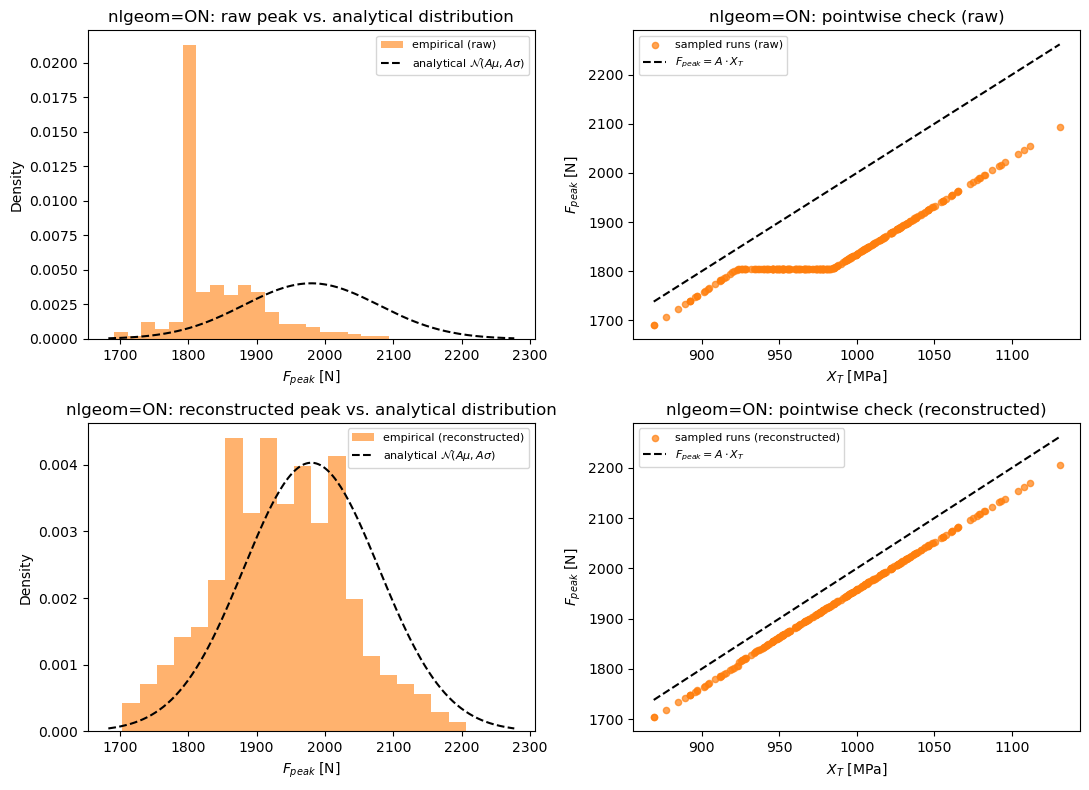

In [25]:
stats_on = analyze_and_plot_campaign(on_data, "nlgeom=ON", color="C1")


**The same raw-vs-reconstructed pattern holds**, printed above: the raw peak again reads low,
and the reconstruction again closes most of that gap.

What is new for `nlgeom=ON` is the question: **is the reconstructed $F_{peak}$ actually Normal?** The figure above cannot answer
that, only fail to contradict it. The bottom-left histogram looks reasonably bell-shaped, and
the bottom-right pointwise scatter still tracks essentially a straight line &ndash; but a
histogram that *looks* symmetric is weak evidence of normality: it can rule normality *out*
decisively (obvious skew, a second mode, heavy tails) but it cannot *confirm* it, since plenty
of non-Normal distributions produce histograms that look similar to a Normal one at this sample
size, especially near the bulk of the distribution rather than out in the tail a percentile
actually targets. What can be said honestly is narrower: the nonlinearity `nlgeom=ON`
introduces here is *gentle* &ndash; a small, smooth correction to an otherwise-linear map, not a
sharp threshold or a qualitative change in behavior, and the essentially linear pointwise scatter shows
this directly. That is enough to treat the reconstructed sample as approximately Normal &ndash; a
defensible judgment call, not a proof &ndash; and to compute its $Q_{5\%}$ the same way as for
`nlgeom=OFF`, next.


Having just judged a Normal description reasonable, the same plug-in estimator applies &ndash;
with the caveat, unlike `nlgeom=OFF`, that here it rests on that judgment call, not a theorem:

$$
\widehat{Q_{5\%}} = \widehat\mu + z_{5\%}\,\widehat\sigma.
$$


In [26]:
q5_on = stats_on["mean_recon"] + Z_P["5%"] * stats_on["std_recon"]

print(f"nlgeom=ON plug-in Q5%: {q5_on:.2f} N")


nlgeom=ON plug-in Q5%: 1778.82 N


### `nlgeom=OFF` vs. `nlgeom=ON`: the direct comparison, and the design message

Both campaigns' Q5% checks side by side, reconstructed peak force only:


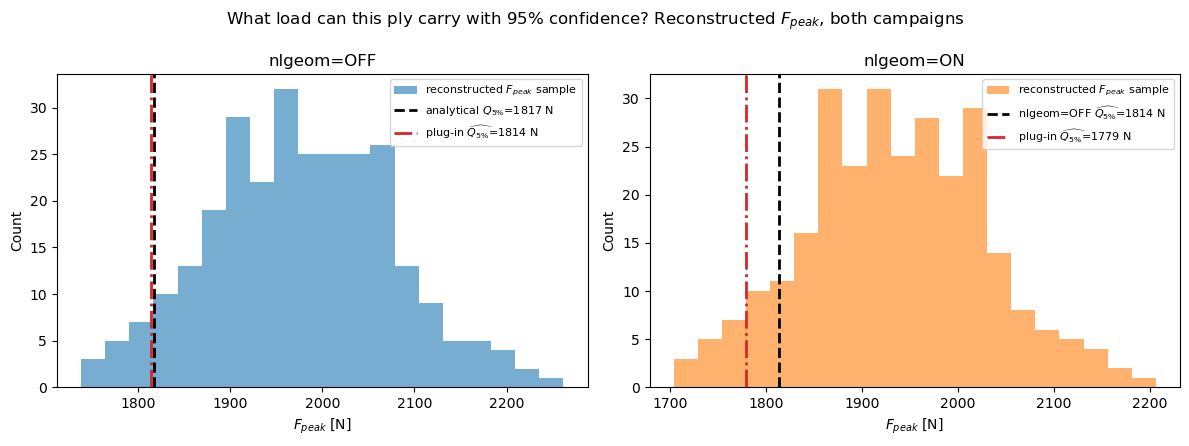

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

f_recon_off = off_data["f_peak_recon"][~np.isnan(off_data["f_peak_recon"])]
axes[0].hist(f_recon_off, bins=min(20, max(3, len(f_recon_off) // 5)),
             color="C0", alpha=0.6, label="reconstructed $F_{peak}$ sample")
axes[0].axvline(analytical_q5, color="k", ls="--", lw=2, label=f"analytical $Q_{{5\\%}}$={analytical_q5:.0f} N")
axes[0].axvline(q5_off, color="C3", ls="-.", lw=2, label=f"plug-in $\\widehat{{Q_{{5\\%}}}}$={q5_off:.0f} N")
axes[0].set_xlabel("$F_{peak}$ [N]")
axes[0].set_ylabel("Count")
axes[0].set_title("nlgeom=OFF")
axes[0].legend(fontsize=8)

# nlgeom=ON's reference line is nlgeom=OFF's own Q5% plug-in, not the analytical value - since
# both campaigns share the identical X_T draw, this is the reference that actually isolates
# what nlgeom=ON changes (quantified in the table below), not a comparison to an answer
# nlgeom=ON was never guaranteed to recover in the first place.
f_recon_on = on_data["f_peak_recon"][~np.isnan(on_data["f_peak_recon"])]
axes[1].hist(f_recon_on, bins=min(20, max(3, len(f_recon_on) // 5)),
             color="C1", alpha=0.6, label="reconstructed $F_{peak}$ sample")
axes[1].axvline(q5_off, color="k", ls="--", lw=2, label=f"nlgeom=OFF $\\widehat{{Q_{{5\\%}}}}$={q5_off:.0f} N")
axes[1].axvline(q5_on, color="C3", ls="-.", lw=2, label=f"plug-in $\\widehat{{Q_{{5\\%}}}}$={q5_on:.0f} N")
axes[1].set_xlabel("$F_{peak}$ [N]")
axes[1].set_ylabel("Count")
axes[1].set_title("nlgeom=ON")
axes[1].legend(fontsize=8)

fig.suptitle(r"What load can this ply carry with 95% confidence? Reconstructed $F_{peak}$, both campaigns")
fig.tight_layout()
plt.show()


`nlgeom=OFF`'s results were checked against the analytical closed form above &ndash; the right
comparison for a campaign built to recover a known answer. `nlgeom=ON` has no such answer to
check against, so the meaningful comparison for it is not to the analytical prediction but to
`nlgeom=OFF` directly: since both campaigns ran the *identical* 280 values of $X_T$, ordinary
sampling noise is common to both and cancels out of their difference, and whatever remains can
only come from the one thing that differs between them, the `nlgeom` setting itself. The table
below makes that comparison precise.


In [28]:
print(f"{'quantity':40s}{'nlgeom=OFF (reconstructed)':>28s}{'nlgeom=ON (reconstructed)':>28s}{'difference':>14s}")
print("-" * 110)
print(f"{'mean F_peak [N]':40s}{stats_off['mean_recon']:28.2f}{stats_on['mean_recon']:28.2f}"
      f"{(stats_on['mean_recon'] - stats_off['mean_recon']):14.2f}")
print(f"{'std F_peak [N]':40s}{stats_off['std_recon']:28.2f}{stats_on['std_recon']:28.2f}"
      f"{(stats_on['std_recon'] - stats_off['std_recon']):14.2f}")
print(f"{'Q5% F_peak [N]':40s}{q5_off:28.2f}{q5_on:28.2f}"
      f"{(q5_on - q5_off):14.2f}")
print()
print(f"Turning nlgeom ON alone shifts the reconstructed mean peak force by "
      f"{(stats_on['mean_recon'] - stats_off['mean_recon']) / stats_off['mean_recon']:.2%}, "
      f"and the Q5% design value by "
      f"{(q5_on - q5_off) / q5_off:.2%}.")


quantity                                  nlgeom=OFF (reconstructed)   nlgeom=ON (reconstructed)    difference
--------------------------------------------------------------------------------------------------------------
mean F_peak [N]                                              1976.45                     1934.92        -41.53
std F_peak [N]                                                 98.91                       94.90         -4.01
Q5% F_peak [N]                                               1813.75                     1778.82        -34.94

Turning nlgeom ON alone shifts the reconstructed mean peak force by -2.10%, and the Q5% design value by -1.93%.


### Why `nlgeom=ON` moves the peak, briefly recalled

Two genuine (not numerical) effects separate the `nlgeom=ON` campaign from the `nlgeom=OFF` campaign, both
consequences of accounting for finite deformation rather than assuming small strain &ndash; fully
derived, with NB1's own baseline run as a worked numerical example, in
[NB1](01_fiber_tension_single_element.ipynb)'s "Why `nlgeom=ON` moves the peak: the
equations" section:

1. **Strain measure.** `nlgeom=ON` uses the logarithmic (true) strain instead of small-strain
   engineering strain, so reaching a given stress $X_T$ takes a slightly larger prescribed
   displacement than the small-strain formula predicts.
2. **Stress measure and the shrinking cross-section.** `nlgeom=ON` works with the true
   (Cauchy) stress on the *current*, Poisson-contracted cross-section rather than the
   original area, so the same $X_T$ corresponds to a slightly *smaller* peak force.

**The design message.** Turning `nlgeom` on shifts the reconstructed $Q_{5\%}$ from
`nlgeom=OFF`'s 1813.75 N to `nlgeom=ON`'s 1778.82 N &ndash; roughly a 1.9% drop. This result means that the geometrically nonlinear analysis, which is the
physically more complete one, shows this ply's actual low-percentile capacity is lower than the linear analysis would suggest. If the small-strain result were used directly as a design allowable, it would be **non-conservative**. Even more interestingly, we can observe that the drop of the mean peak force from linear to nonlinear analysis is not identical to the drop of the 5th percentile. Even though the difference is pretty small in this case (as it can be expected given the simple nature of the single-shell-element problem), it shows a concrete reason why geometric nonlinearity has to sit *inside* the
uncertainty-quantification loop itself: once the input-output map stops being linear, its effect on
the *tail* of the output distribution has to be captured by the full random sample, not
assumed to simply shift every percentile by the same amount the mean shifts by.


## Conclusion

This notebook built the first step of a uncertainty-quantification pipeline around
one central idea: build a trustworthy **distribution of the output**, $F_{peak}$, and a design-relevant percentile read off it with
actual evidence.

**What this notebook established:**

- **A random variable, its distribution, and the one case where the output distribution can
  be written down exactly.** $X_T$ became a Normal random variable (Part 1), explicitly named
  as a simplification &ndash; the 5% CoV traced to
  [Sriramula & Chryssanthopoulos (2009)](https://doi.org/10.1016/j.compositesa.2009.08.020),
  the unphysical negative tail and the [Weibull (1951)](https://doi.org/10.1115/1.4010337)
  alternative both named honestly. Because $F_{peak}=A\cdot X_T$ is an *exactly linear* map,
  its entire distribution followed directly, with no Abaqus run needed &ndash; a special case,
  not the general rule.
- **A sample size derived analytically, by deliberately exploiting that special case, and
  verified against three actual random seeds** &ndash; not just trusted on theory. Targeting a
  1% relative standard error on $\widehat{Q_{5\%}}$, combined in quadrature from
  $SE(\widehat\mu)$ and $SE(\widehat\sigma)$ (Part 2), gave $N=280$; both the 1% target and the
  5th percentile are illustrative choices a real study would instead take from engineering
  judgement or a design code. This a-priori shortcut only works because $X_T$ is Normal and the
  map is linear &ndash; a general problem has no closed form to size $N$ against, and would have
  to monitor convergence as samples are added instead.
- **The raw peak force materially under-reports uncertainty, regardless of `nlgeom`** &ndash;
  29.8% (`nlgeom=OFF`) and 34.9% (`nlgeom=ON`) low on standard deviation against the analytical
  prediction. NB1's double-linear-fit reconstruction recovered both campaigns' means and
  standard deviations to within a few percent.
- **`nlgeom=OFF` verified the pipeline against a known answer; `nlgeom=ON` is the case this
  notebook was actually building toward.** `nlgeom=OFF`'s reconstructed statistics matched both
  the analytical closed form and this campaign's own realized input sample almost exactly.
  `nlgeom=ON` breaks the exactly-linear map, so mean and std are no longer guaranteed to
  determine its percentiles the way they provably do for `nlgeom=OFF`; its bell-shaped
  histogram and essentially linear pointwise scatter made that two-parameter shortcut a defensible
  judgment call, not a certainty.
- **The headline result: turning `nlgeom` on shifts the mean down by about 2.1% and the 5th-percentile down by
  about 1.9%**, relative to `nlgeom=OFF`'s own result. A small-strain-only analysis would overstate this ply's
  low-percentile load-carrying capacity; geometric nonlinearity has to be inside the
  uncertainty-quantification loop, not corrected for afterward, because the mean and the tail do not have to shift by the same amount.

**Where this goes next.** Two simplifications flagged along the way are the natural next steps
once this pipeline is trusted for one random input: scatter data from a source that actually
reports it (rather than this notebook's illustrative 5% CoV), and the
[Weibull (1951)](https://doi.org/10.1115/1.4010337) distribution in place of the Normal &ndash;
the standard choice for brittle-fiber tensile strength via weakest-link theory, removing the
unphysical negative-strength tail carried throughout as an accepted simplification, and
finally *answering*, rather than merely finding plausible, whether a nonlinear map's output is
really Normal.

Beyond that, the real challenge is scaling this approach up to a **full laminate with
manufacturing defects** &ndash; voids, ply waviness, resin-rich zones, and other sources of variability.
That setting has *several* uncertain inputs instead of one, each spatially varying rather than
a single scalar; a mesh with enough elements that a single Abaqus run costs far more than the
roughly 20 seconds of solve time each single-element run here took; and, critically, no exact closed form left to
check against for even the linear-elastic regime, let alone the fully nonlinear one. A vanilla
Monte Carlo $N$ sized the way Part 2 sizes it here would likely become computationally
unaffordable at that scale &ndash; exactly the setting where uncertainty quantification for
progressive damage analysis is most needed, and where variance-reduction techniques or cheap
surrogate models (rather than one Abaqus job per sample) stop being optional refinements and
become the only way to get an answer at all.
